# Synaptic Plasticity: From Static Synapses to STDP

**綜合教程：靜態突觸、動態突觸與 Spike-Timing Dependent Plasticity**

Based on Neuromatch Academy: Computational Neuroscience (W2D4)

---

## Tutorial Objectives

本教程涵蓋兩大主題：

### Part 1: 靜態與動態突觸 (Static and Dynamic Synapses)
- 模擬靜態突觸，研究興奮和抑制如何影響神經元輸出
- 定義均值驅動和波動驅動機制
- 模擬短期突觸可塑性 (Short-Term Plasticity: STD/STF)

### Part 2: STDP (Spike-Timing Dependent Plasticity)
- 建立 STDP 突觸模型
- 研究輸入 spike train 相關性如何影響突觸權重分布

## Setup

In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import time

# Import all functions from lif_utils
from lif_utils import (
    default_pars,
    Poisson_generator,
    my_GWN,
    run_LIF_cond,
    dynamic_syn,
    default_pars_STDP,
    Delta_W,
    generate_P,
    run_LIF_cond_STDP,
    plot_volt_trace,
    my_raster_plot,
    my_illus_LIFSYN,
    plot_STDP_kernel,
    plot_spike_raster
)

# Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
%config InlineBackend.figure_format='retina'

# Try to use NMA plot style, fallback to default if not available
try:
    plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")
except:
    print("Using default matplotlib style")



# Part 1: Static and Dynamic Synapses

---

<font size=6>
注意這裡再講的東西跟後面的 STDP 有差異，這裡是 突觸前神經元 (Pre) 自己的 spike 打出來後，突觸前末梢的行為
</font>

---

## Section 1.1: Introduction to Synaptic Transmission

突觸將神經元連接成神經網路。本教程聚焦於**化學突觸**，這是大腦中最常見的突觸類型。

### 突觸電導動力學

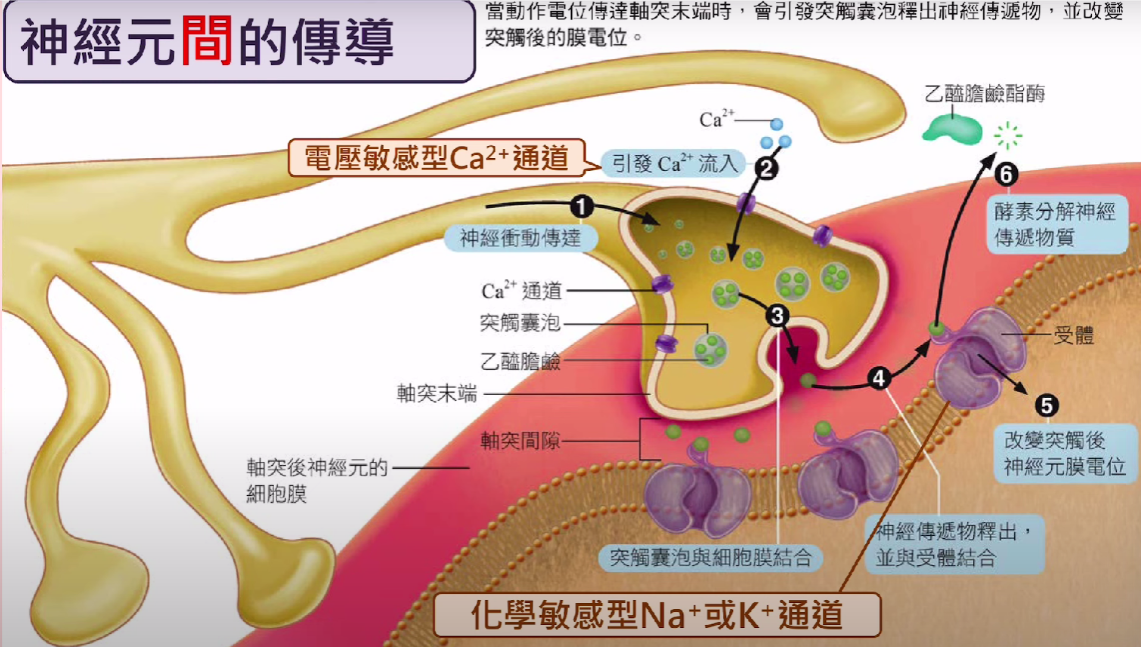

1. 代表前面的電訊號傳遞
2. 這個電訊號觸發 $Ca^{2+}$ 通道蛋白 (VGCC) 讓 $Ca^{2+}$ 進入
3. $Ca^{2+}$ 讓囊泡內的神經傳遞物質(ex: 多巴胺，乙醯膽鹼，血清素) 釋放
4. 開始擴散給下一個神經細胞的受體接收
5. 受體接收到神經傳導物質會開啟對應離子的通道蛋白 ex: $Na^+$, $Cl^-$ (注意是多對多的關係，多個神經傳導物質對應多個通道蛋白)
6. 根據第 5 可以看到，有正負電流的流入，這稱為 EPSP/IPSP，這會改變膜電位，並根據總和觸發下一個細胞的訊號
7. 分解神經傳遞物質

---

突觸輸入由**興奮性**和**抑制性**神經遞質混合組成：
- **興奮性 (Excitatory)**: 使細胞去極化，推向 spike 閾值
- **抑制性 (Inhibitory)**: 使細胞超極化，遠離 spike 閾值

電導瞬變可以用 ODE 生成：

$$\frac{dg_{\rm syn}(t)}{dt} = \bar{g}_{\rm syn} \sum_k \delta(t-t_k) - g_{\rm syn}(t)/\tau_{\rm syn}$$

其中：

- $\delta(t - t_k) = \begin{cases}
  \infty, t = t_k\\
  0, t \ne t_k
\end{cases}$
    - 只有當 $t = t_k$ 的時候是無限，其餘皆 0
- $\bar{g}_{\rm syn}$: 突觸權重（每個傳入 spike 引發的最大電導）
- $\tau_{\rm syn}$: 突觸時間常數

這個函數的意義是
* 輸入神經元有**一個**，這個神經元在 $t_1, t_2, ...$ 的時候發出 spike
    * 為了讓函數能夠在 $t >= 0$ 都成立，所以使用 $\Sigma$
    * 每次觸發都會讓變化率提高，提高的量由權重 $\bar{g}_{\rm syn}$ 決定
* 後面 $-g_{\rm syn}(t)/\tau_{\rm syn}$ 就是為了平常保持 0

---

突觸電流由歐姆定律給出：

$$I_{\rm syn}(t) = g_{\rm syn}(t)(V(t)-E_{\rm syn})$$

* 這個電流就是神經物質觸發 $Ca^{2+}$, $Cl^{-}$ 流入的電流
* $E_{\rm syn}$ 就是平時應該維持的目標電位

## Section 1.2: Conductance-based LIF Neuron

總突觸電流是興奮性和抑制性輸入的總和：

$$I_{\rm syn}(V(t),t) = -g_E(t)(V(t)-E_E) - g_I(t)(V(t)-E_I)$$

LIF 神經元在突觸電流驅動下的膜電位動力學，也就是加上 $I_{\rm syn}$：

$$\tau_m\frac{dV(t)}{dt} = -(V(t)-E_L) - \frac{g_E(t)}{g_L}(V(t)-E_E) - \frac{g_I(t)}{g_L}(V(t)-E_I) + \frac{I_{\rm inj}}{g_L}$$


### Exercise 1.2: Measure the Free Membrane Potential (FMP)

* **自由膜電位 (Free Membrane Potential, FMP)** 是當 spike 閾值被移除時神經元的膜電位。
* 雖然這是人為的，但計算 FMP 可以讓我們了解輸入的強度。

---

以下就是原本的 LIF 加上 80 個興奮突觸，20 個抑制突觸，spike 直接用 Poisson 模擬

自由膜電位就是不觸發 spike，即使遇到 $V_{th}$ 也不會觸發 spike，可以發現兩條曲線 spike 後會被打散，但只要有一定時間就會重疊回去


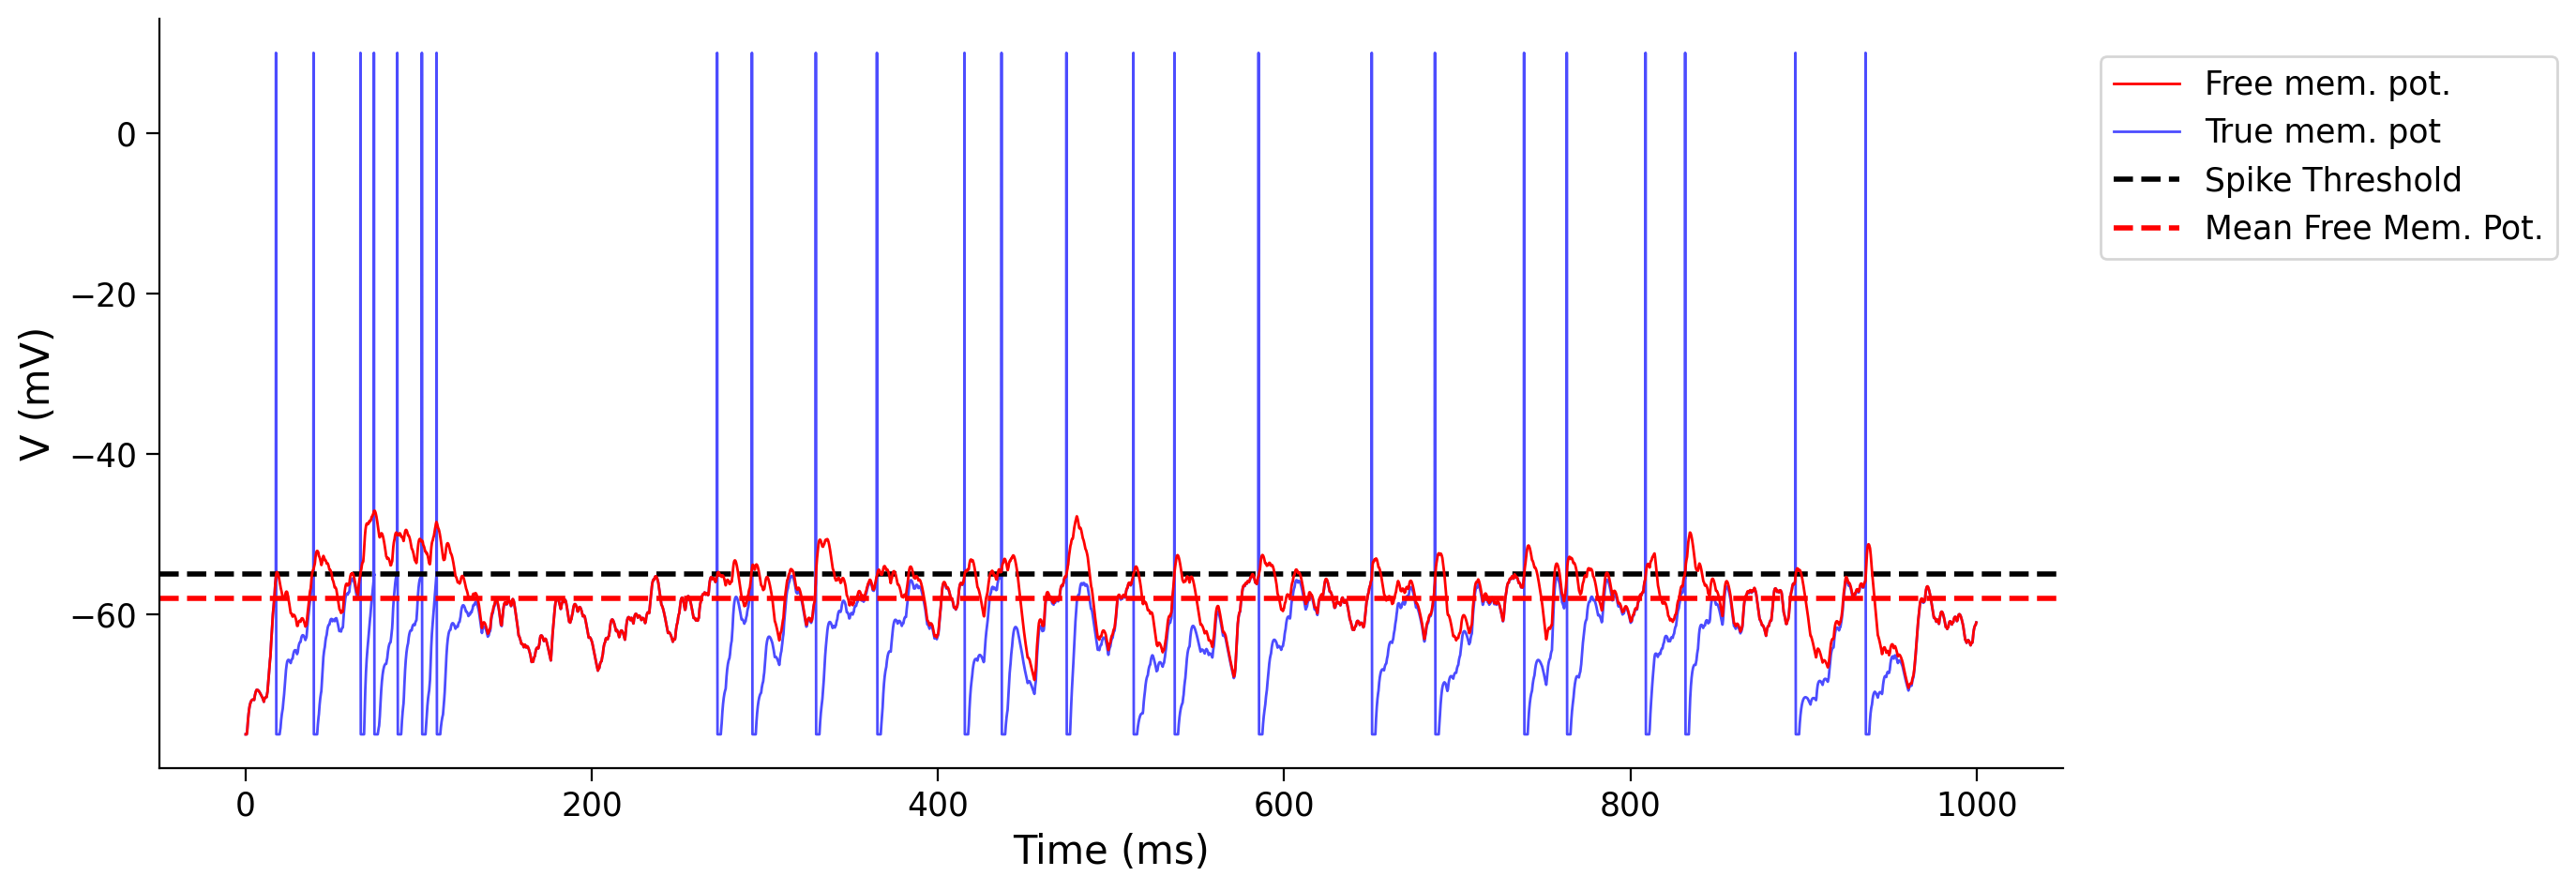

Mean Free Membrane Potential: -58.10 mV
Std of Free Membrane Potential: 4.09 mV


In [2]:
# Set up parameters
pars = default_pars(T=1000.)

# Add synaptic parameters
pars['gE_bar'] = 2.4     # [nS] excitatory conductance
pars['VE'] = 0.          # [mV] excitatory reversal potential
pars['tau_syn_E'] = 2.   # [ms] excitatory time constant
pars['gI_bar'] = 2.4     # [nS] inhibitory conductance
pars['VI'] = -80.        # [mV] inhibitory reversal potential
pars['tau_syn_I'] = 5.   # [ms] inhibitory time constant
pars['E_L'] = pars['V_L']  # Ensure E_L is set

# Generate presynaptic spike trains
pre_spike_train_ex = Poisson_generator(pars, rate=10, n=80)
pre_spike_train_in = Poisson_generator(pars, rate=10, n=20)

# Simulate conductance-based LIF model (using Brian2)
v, rec_spikes, gE, gI = run_LIF_cond(pars, 0, pre_spike_train_ex, pre_spike_train_in)

# Show spikes more clearly
dt, range_t = pars['dt'], pars['range_t']
if rec_spikes.size:
    sp_num = (rec_spikes / dt).astype(int) - 1
    sp_num = sp_num[sp_num < len(v)]
    v[sp_num] = 10

# Calculate Free Membrane Potential (set threshold very high to prevent firing)
pars_fmp = pars.copy()
pars_fmp['V_th'] = 1e3  # Very high threshold

v_fmp, _, _, _ = run_LIF_cond(pars_fmp, 0, pre_spike_train_ex, pre_spike_train_in)

# Plot
my_illus_LIFSYN(pars, v_fmp, v)

print(f"Mean Free Membrane Potential: {np.mean(v_fmp):.2f} mV")
print(f"Std of Free Membrane Potential: {np.std(v_fmp):.2f} mV")

### Interactive Demo: E/I Balance

研究興奮性和抑制性輸入比例如何影響發射率和 spike 時間規律性。

關鍵概念：
- 當 FMP 均值在閾值**以上**時：均值驅動機制 (mean-driven regime)
- 當 FMP 均值在閾值**以下**時：波動驅動機制 (fluctuation-driven regime)，spike 更不規律

Case 1: Low inhibition (mean-driven regime)

Case 2: High inhibition (fluctuation-driven regime)


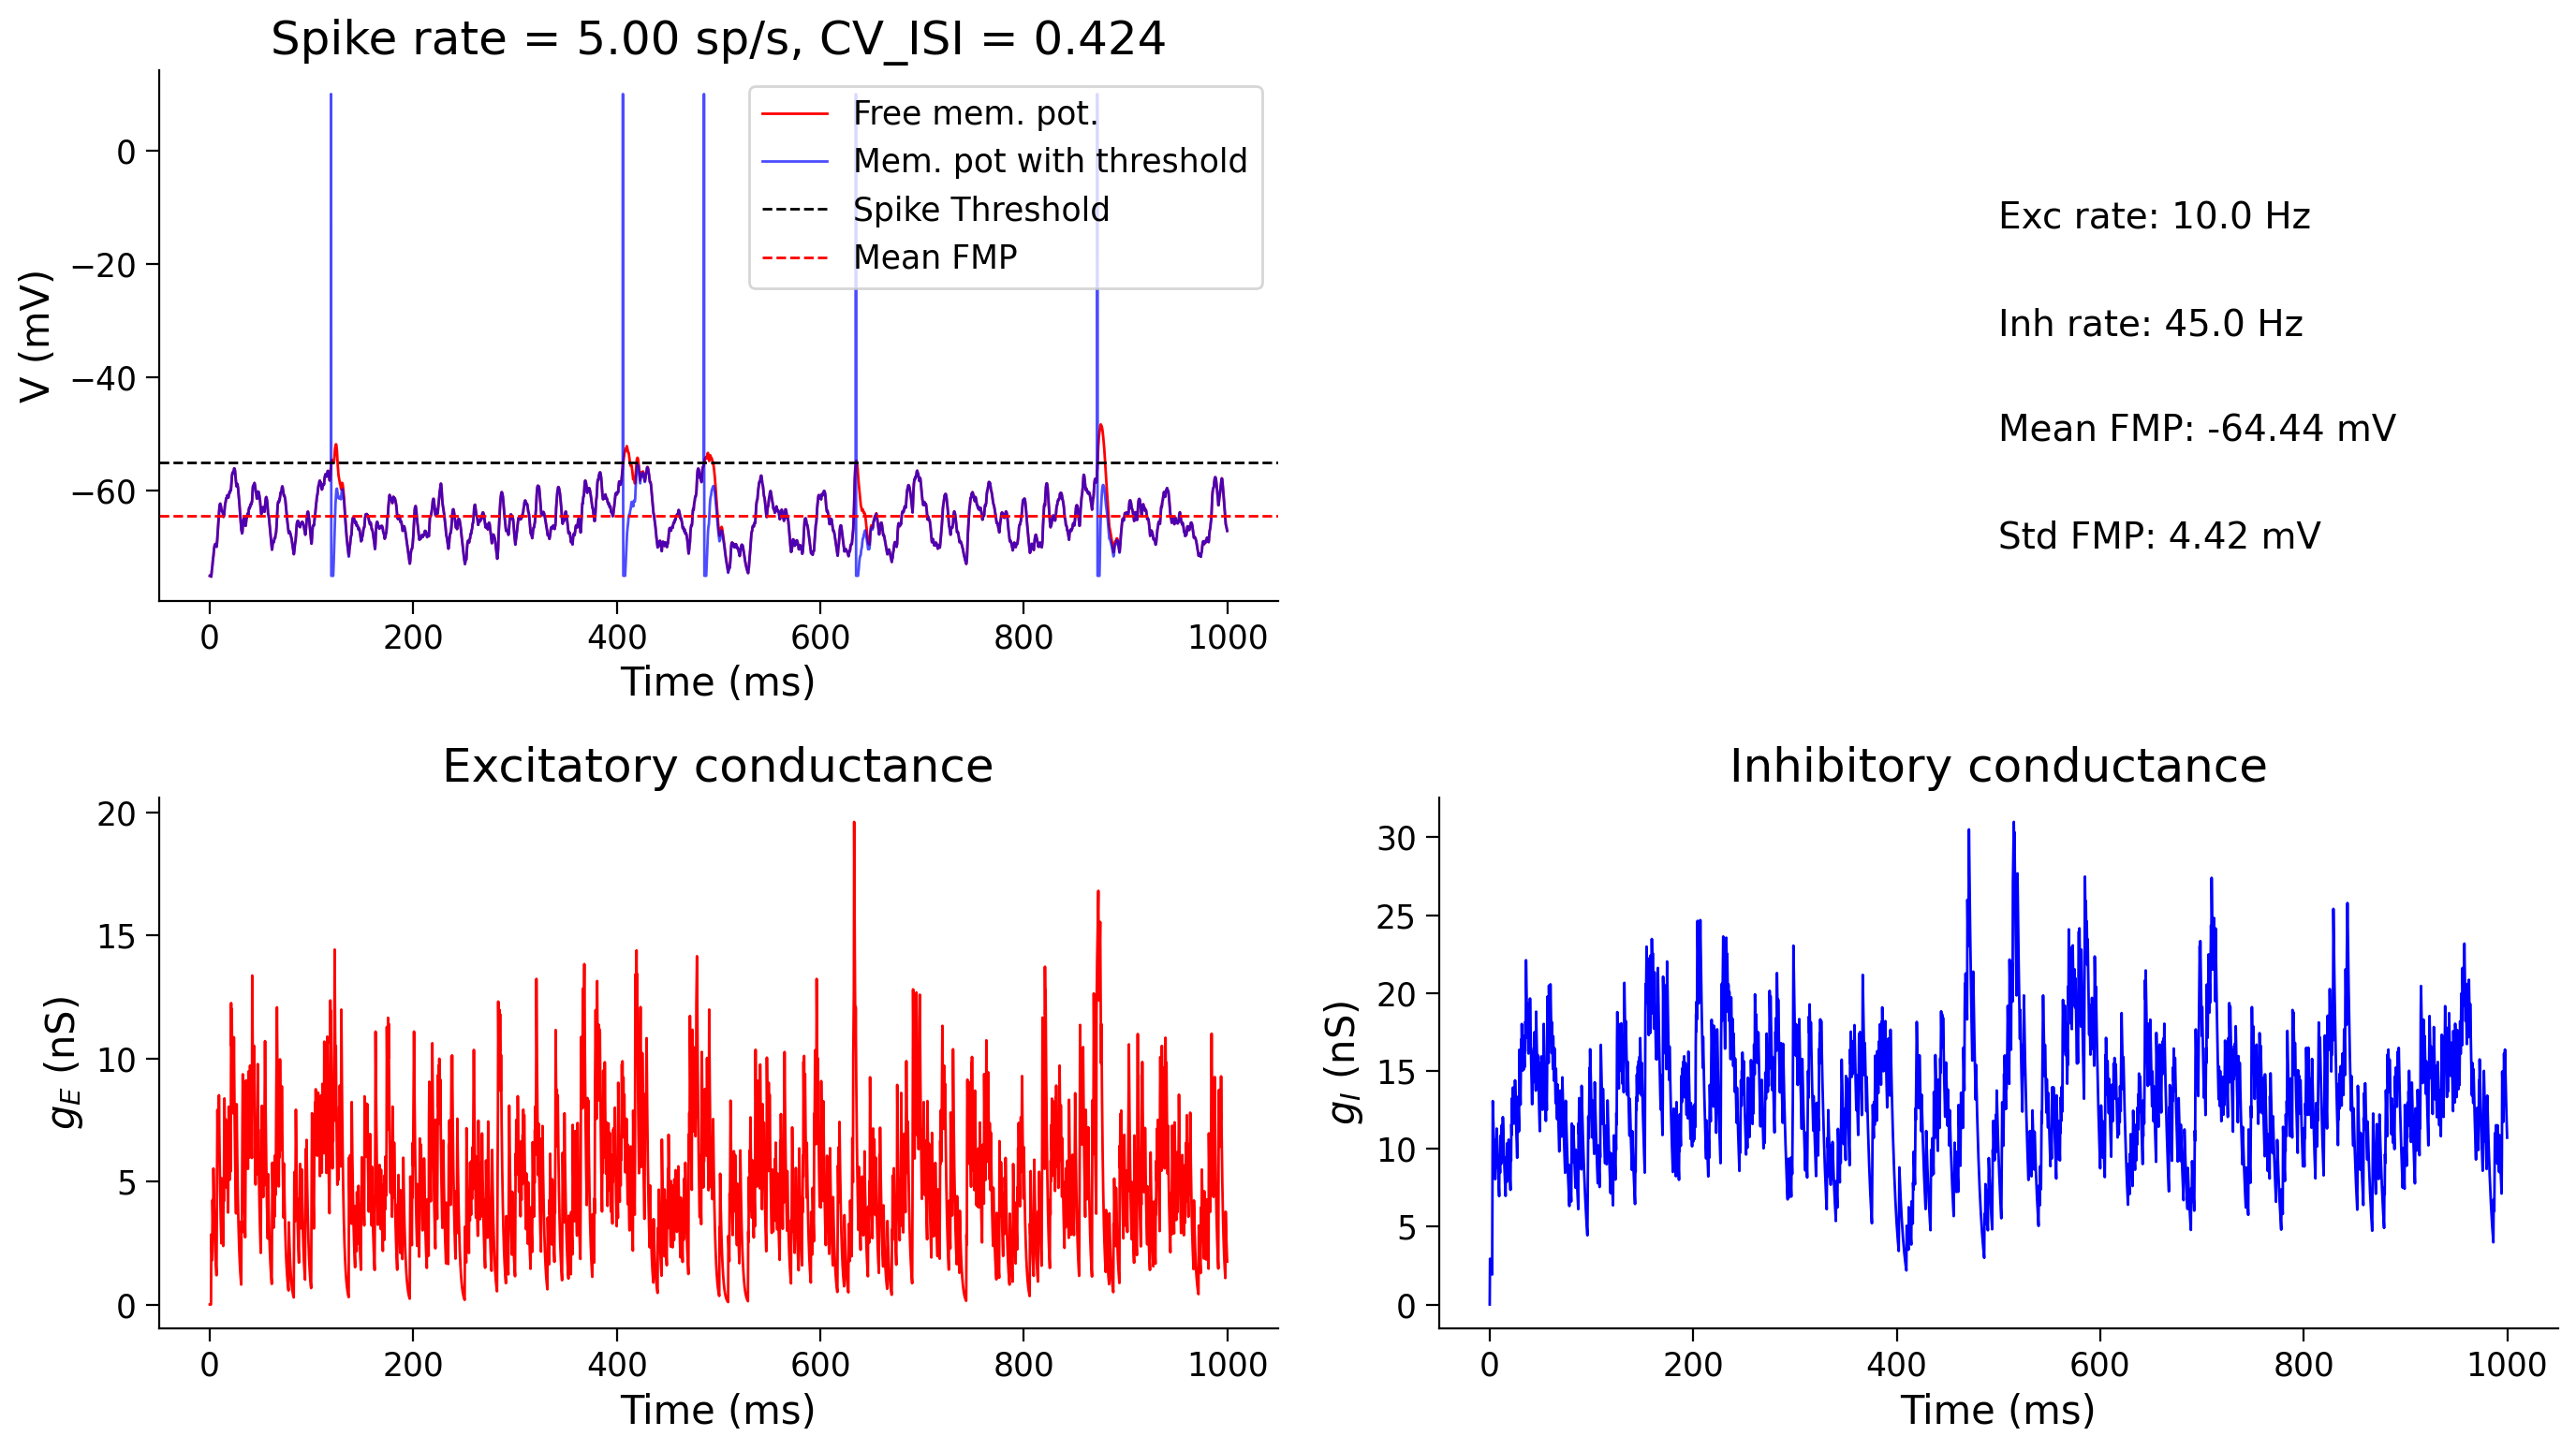

(5.0, np.float64(0.42362812354863233))

In [3]:
def simulate_EI_balance(exc_rate=10., inh_rate=20.):
    """
    Simulate LIF neuron with different E/I balance using Brian2.
    """
    pars = default_pars(T=1000.)
    pars['gE_bar'] = 3.
    pars['VE'] = 0.
    pars['tau_syn_E'] = 2.

    pars['gI_bar'] = 3.
    pars['VI'] = -80.
    pars['tau_syn_I'] = 5.
    
    pars['E_L'] = pars['V_L']

    pre_spike_train_ex = Poisson_generator(pars, rate=exc_rate, n=80)
    pre_spike_train_in = Poisson_generator(pars, rate=inh_rate, n=20)

    # Calculate FMP (no spike threshold)
    pars_temp = pars.copy()
    pars_temp['V_th'] = 1e3
    v_fmp, _, gE, gI = run_LIF_cond(pars_temp, 
                                    0, 
                                    pre_spike_train_ex, 
                                    pre_spike_train_in)

    # Normal simulation
    pars['V_th'] = -55.
    v, rec_spikes, gE, gI = run_LIF_cond(pars, 
                                         0, 
                                         pre_spike_train_ex, 
                                         pre_spike_train_in)

    dt = pars['dt']
    if rec_spikes.size:
        sp_num = (rec_spikes / dt).astype(int) - 1
        sp_num = sp_num[sp_num < len(v)]
        v[sp_num] = 10

    spike_rate = 1e3 * len(rec_spikes) / pars['T']

    cv_isi = 0.
    if len(rec_spikes) > 3:
        isi = np.diff(rec_spikes)
        cv_isi = np.std(isi) / np.mean(isi)

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(pars['range_t'], v_fmp, 'r', lw=1., label='Free mem. pot.')
    axes[0, 0].plot(pars['range_t'], v, 'b', lw=1., label='Mem. pot with threshold', alpha=0.7)
    axes[0, 0].axhline(pars['V_th'], 0, 1, color='k', lw=1., ls='--', label='Spike Threshold')
    axes[0, 0].axhline(np.mean(v_fmp), 0, 1, color='r', lw=1., ls='--', label='Mean FMP')
    axes[0, 0].set_xlabel('Time (ms)')
    axes[0, 0].set_ylabel('V (mV)')
    axes[0, 0].legend(loc='upper right')
    axes[0, 0].set_title(f'Spike rate = {spike_rate:.2f} sp/s, CV_ISI = {cv_isi:.3f}')

    axes[0, 1].text(0.5, 0.7, f'Exc rate: {exc_rate} Hz', fontsize=14, transform=axes[0, 1].transAxes)
    axes[0, 1].text(0.5, 0.5, f'Inh rate: {inh_rate} Hz', fontsize=14, transform=axes[0, 1].transAxes)
    axes[0, 1].text(0.5, 0.3, f'Mean FMP: {np.mean(v_fmp):.2f} mV', fontsize=14, transform=axes[0, 1].transAxes)
    axes[0, 1].text(0.5, 0.1, f'Std FMP: {np.std(v_fmp):.2f} mV', fontsize=14, transform=axes[0, 1].transAxes)
    axes[0, 1].axis('off')

    axes[1, 0].plot(pars['range_t'][::3], gE[::3], 'r', lw=1)
    axes[1, 0].set_xlabel('Time (ms)')
    axes[1, 0].set_ylabel(r'$g_E$ (nS)')
    axes[1, 0].set_title('Excitatory conductance')

    axes[1, 1].plot(pars['range_t'][::3], gI[::3], 'b', lw=1)
    axes[1, 1].set_xlabel('Time (ms)')
    axes[1, 1].set_ylabel(r'$g_I$ (nS)')
    axes[1, 1].set_title('Inhibitory conductance')

    plt.tight_layout()
    plt.show()

    return spike_rate, cv_isi


# Try different E/I balance conditions
print("=" * 50)
print("Case 1: Low inhibition (mean-driven regime)")
print("=" * 50)
# simulate_EI_balance(exc_rate=10., inh_rate=10.)

print("\n" + "=" * 50)
print("Case 2: High inhibition (fluctuation-driven regime)")
print("=" * 50)
simulate_EI_balance(exc_rate=10., inh_rate=45.) #

### 問題一：如何讓神經元發出「不規則（泊松型）」的尖峰？

1. 要讓平均膜電位保持 < 閾值
2. 這樣想要產生 spike 的話就得靠運氣，例如興奮突然大一點點，抑制突然小一點點

### 問題二：保持 E/I 平衡時，同時增加雙方輸入，放電率會怎樣？

* 也就是兩股力量都很強大
* 一個直覺的觀念: 
    * $E[X - Y] = E[X] - E[Y]$
    * $Var[X - Y] = Var[X] + Var[Y]$
* 因此會變得更混亂，雜訊會更大


## Section 2: Short-Term Synaptic Plasticity (STP)

**短期可塑性 (STP)** 是突觸效能隨時間變化的現象，反映了突觸前活動的歷史。

兩種類型：
- **短期抑制 (STD, Short-Term Depression)**: 突觸效能降低
- **短期易化 (STF, Short-Term Facilitation)**: 突觸效能增加

### 數學模型

STP 模型基於有限的突觸資源池 $R$ 和釋放概率 $u$：

這裡再說明，突觸**前**神經元發出 spike 後怎麼提高囊泡釋放機率，囊泡釋放後，囊泡的比例衰減，以及囊泡釋放的神經物質最後怎麼影響突觸**後**神經元的電導

* $\frac{du}{dt} = -\frac{u}{\tau_f} + U_0(1-u^-)\delta(t-t_{\rm sp})$
    * $u$ 表示會有多少比例的囊泡釋放神經物質(常態為 $0$)
    * $U_0$ 表示基礎比例
    * $1 - u^-$ 表示比例不會超過 $100\%$
    * $\delta(t-t_{\rm sp})$ 表示突觸前神經元 spike 後會導致上升
    * 這裡就是在講 STF，隨著 spike 的觸發，$Ca^{2+}$ 湧入，**囊泡破裂的比例提升**
* $\frac{dR}{dt} = \frac{1-R}{\tau_d} - u^+ R^- \delta(t-t_{\rm sp})$
    * $R$ 表示所剩餘的囊泡數量(常態為 $1$)
    * $- u^+ R^- \delta(t-t_{\rm sp})$ 表示突觸後有多少比例的囊泡會消失
        * 用更新完的比例 $u^+$ 看實際會消耗 $R^-$ 多少量最後影響 $R^+$
    * 這裡就是在講 STD，隨著 spike 的觸發，**囊泡破裂的比例提升**，但也因此不斷消耗囊泡
* $\frac{dg(t)}{dt} = -\frac{g}{\tau} + \bar{g} u^+ R^- \delta(t-t_{\rm sp})$
    * $g$ 就是被影響的突觸後神經元的電導
    * $u^+ R^-$ 就是前面那條公式，消耗了多少囊泡，也就是釋放多少神經物質
        這裡就是 STF, STD 的制衡
    * $\bar{g}$ 就是權重

---
* $\frac{du}{dt} = -\frac{u}{\tau_f} + ...$ 
    * $u$ 衰減變化率會因為 $\tau_f$ 變大，導致衰減變少
* $\frac{dR}{dt} = \frac{1-R}{\tau_d} - ...$
    * $R$ 提升變化率會因為 $\tau_d$ 變小，導致提升率變高

因此

* $\tau_d \gg \tau_f$ 且 $U_0$ 大：**STD 主導**
* $\tau_d \ll \tau_f$ 且 $U_0$ 小：**STF 主導**

**注意**: `dynamic_syn()` 函數使用 Brian2 實現。

In [4]:
def illustrate_STP(rate=20., U0=0.5, tau_d=100., tau_f=50., title="Short-Term Plasticity"):
    """
    Illustrate short-term plasticity dynamics using Brian2.
    """
    T_simu = 10.0 * 1000 / (1.0 * rate)  # 10 spikes in time window
    pars = default_pars(T=T_simu)
    dt = pars['dt']

    # Regular firing rate
    isi_num = int((1e3/rate)/dt)
    pre_spike_train = np.zeros(len(pars['range_t']))
    pre_spike_train[::isi_num] = 1.

    # Use Brian2-based dynamic_syn
    u, R, g = dynamic_syn(g_bar=1.2, tau_syn=5., U0=U0,
                          tau_d=tau_d, tau_f=tau_f,
                          pre_spike_train=pre_spike_train,
                          dt=pars['dt'])

    plt.figure(figsize=(12, 6))
    plt.suptitle(title, fontsize=14, fontweight='bold')

    plt.subplot(221)
    plt.plot(pars['range_t'], R, 'b', label='R (resources)')
    plt.plot(pars['range_t'], u, 'r', label='u (release prob.)')
    plt.legend(loc='best')
    plt.xlim((0, pars['T']))
    plt.ylabel(r'$R$ or $u$ (a.u)')
    plt.xlabel('Time (ms)')

    plt.subplot(223)
    spT = pre_spike_train > 0
    t_sp = pars['range_t'][spT]
    plt.plot(t_sp, 0. * np.ones(len(t_sp)), 'k|', ms=18, markeredgewidth=2)
    plt.xlabel('Time (ms)')
    plt.xlim((0, pars['T']))
    plt.yticks([])
    plt.title('Presynaptic spikes')

    plt.subplot(122)
    plt.plot(pars['range_t'], g, 'r', label='STP synapse')
    plt.xlabel('Time (ms)')
    plt.ylabel('g (nS)')
    plt.xlim((0, pars['T']))
    plt.title('Synaptic conductance')

    plt.tight_layout()
    plt.show()

    return g[isi_num], g[9*isi_num]

### Demo: Short-Term Depression (STD)

* 這裡想表達的是在 STD 的情況下，$g$ 的狀態如何，可以看到一開始最高，但之後越來越低(抑制)
* 在頻率變高的時候，抑制更明顯
* 抑制就是 $\tau_d >> \tau_f$

---

直觀的流程

1. 前面的神經元發 spike
2. $u$ 會瞬間飆高成 $u+$ **(根據 $U_0, u^-$ )**
3. $R$ 會瞬間降低成 $R^+$ 
    * 消耗的量根據 **($u^+, R^-$)**
4. $g$ 會瞬間標高，根據 **($u^+, R^-$)**
    * 此時 $u^+$ 是一個大的值
        * 顯示在下圖會是 $u$ 的尖峰點
    * $R^-$ 也是相對大的值
        * 顯示在下圖會是 $R$ 的尖峰點
    * $g$ 的變化會正比於 $u^+, R^-$ 因此也會出現尖峰點

Short-Term Depression (STD)
Parameters: U0=0.5, tau_d=100ms, tau_f=50ms


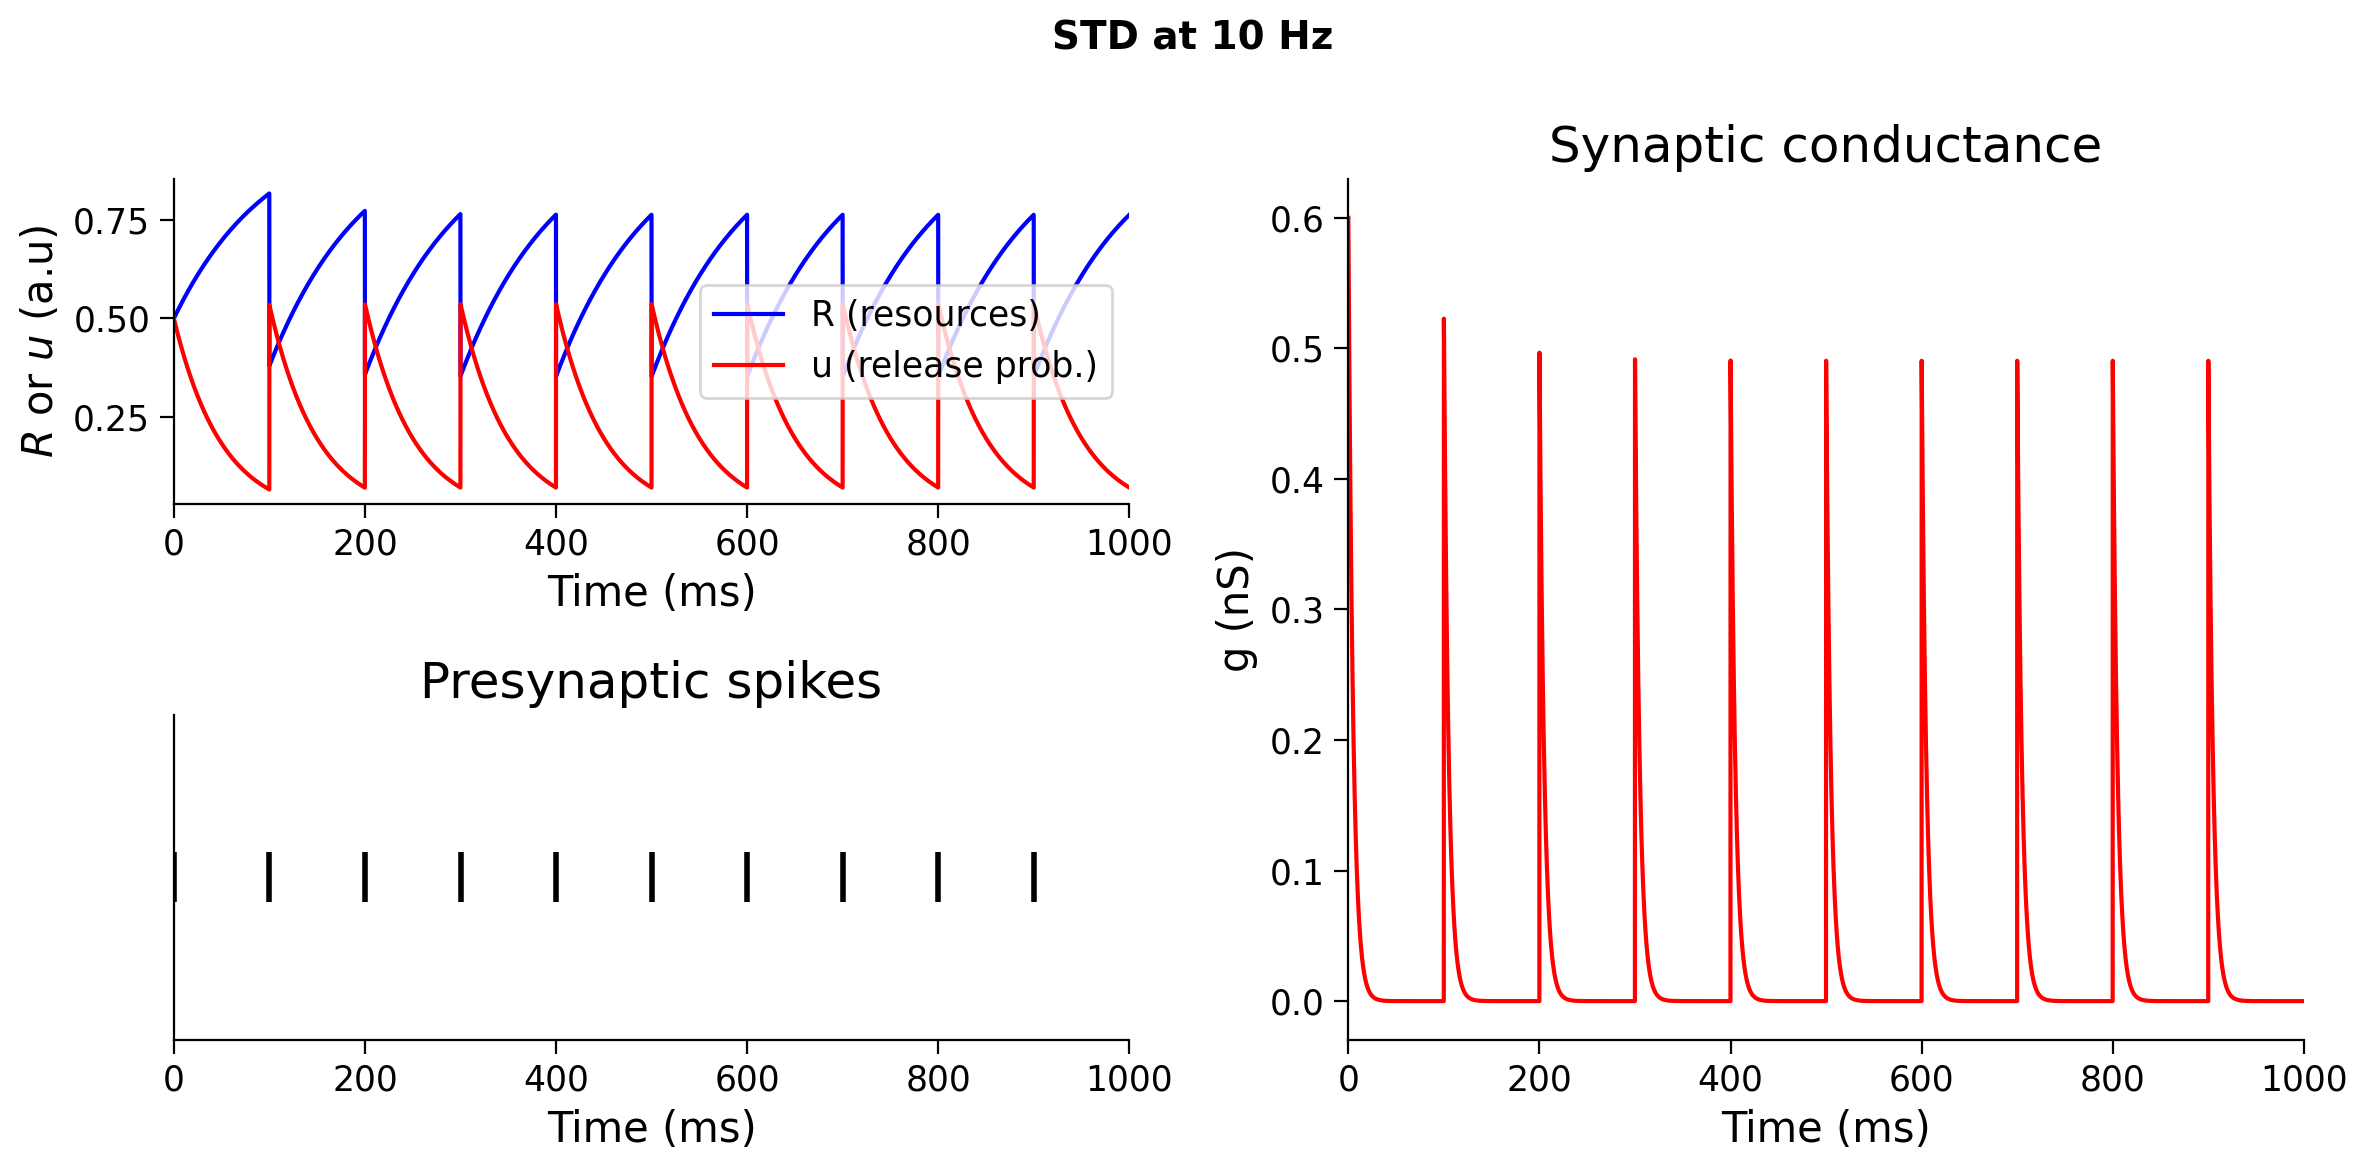

10 Hz: g1=0.5228, g10=0.4905, ratio=0.938


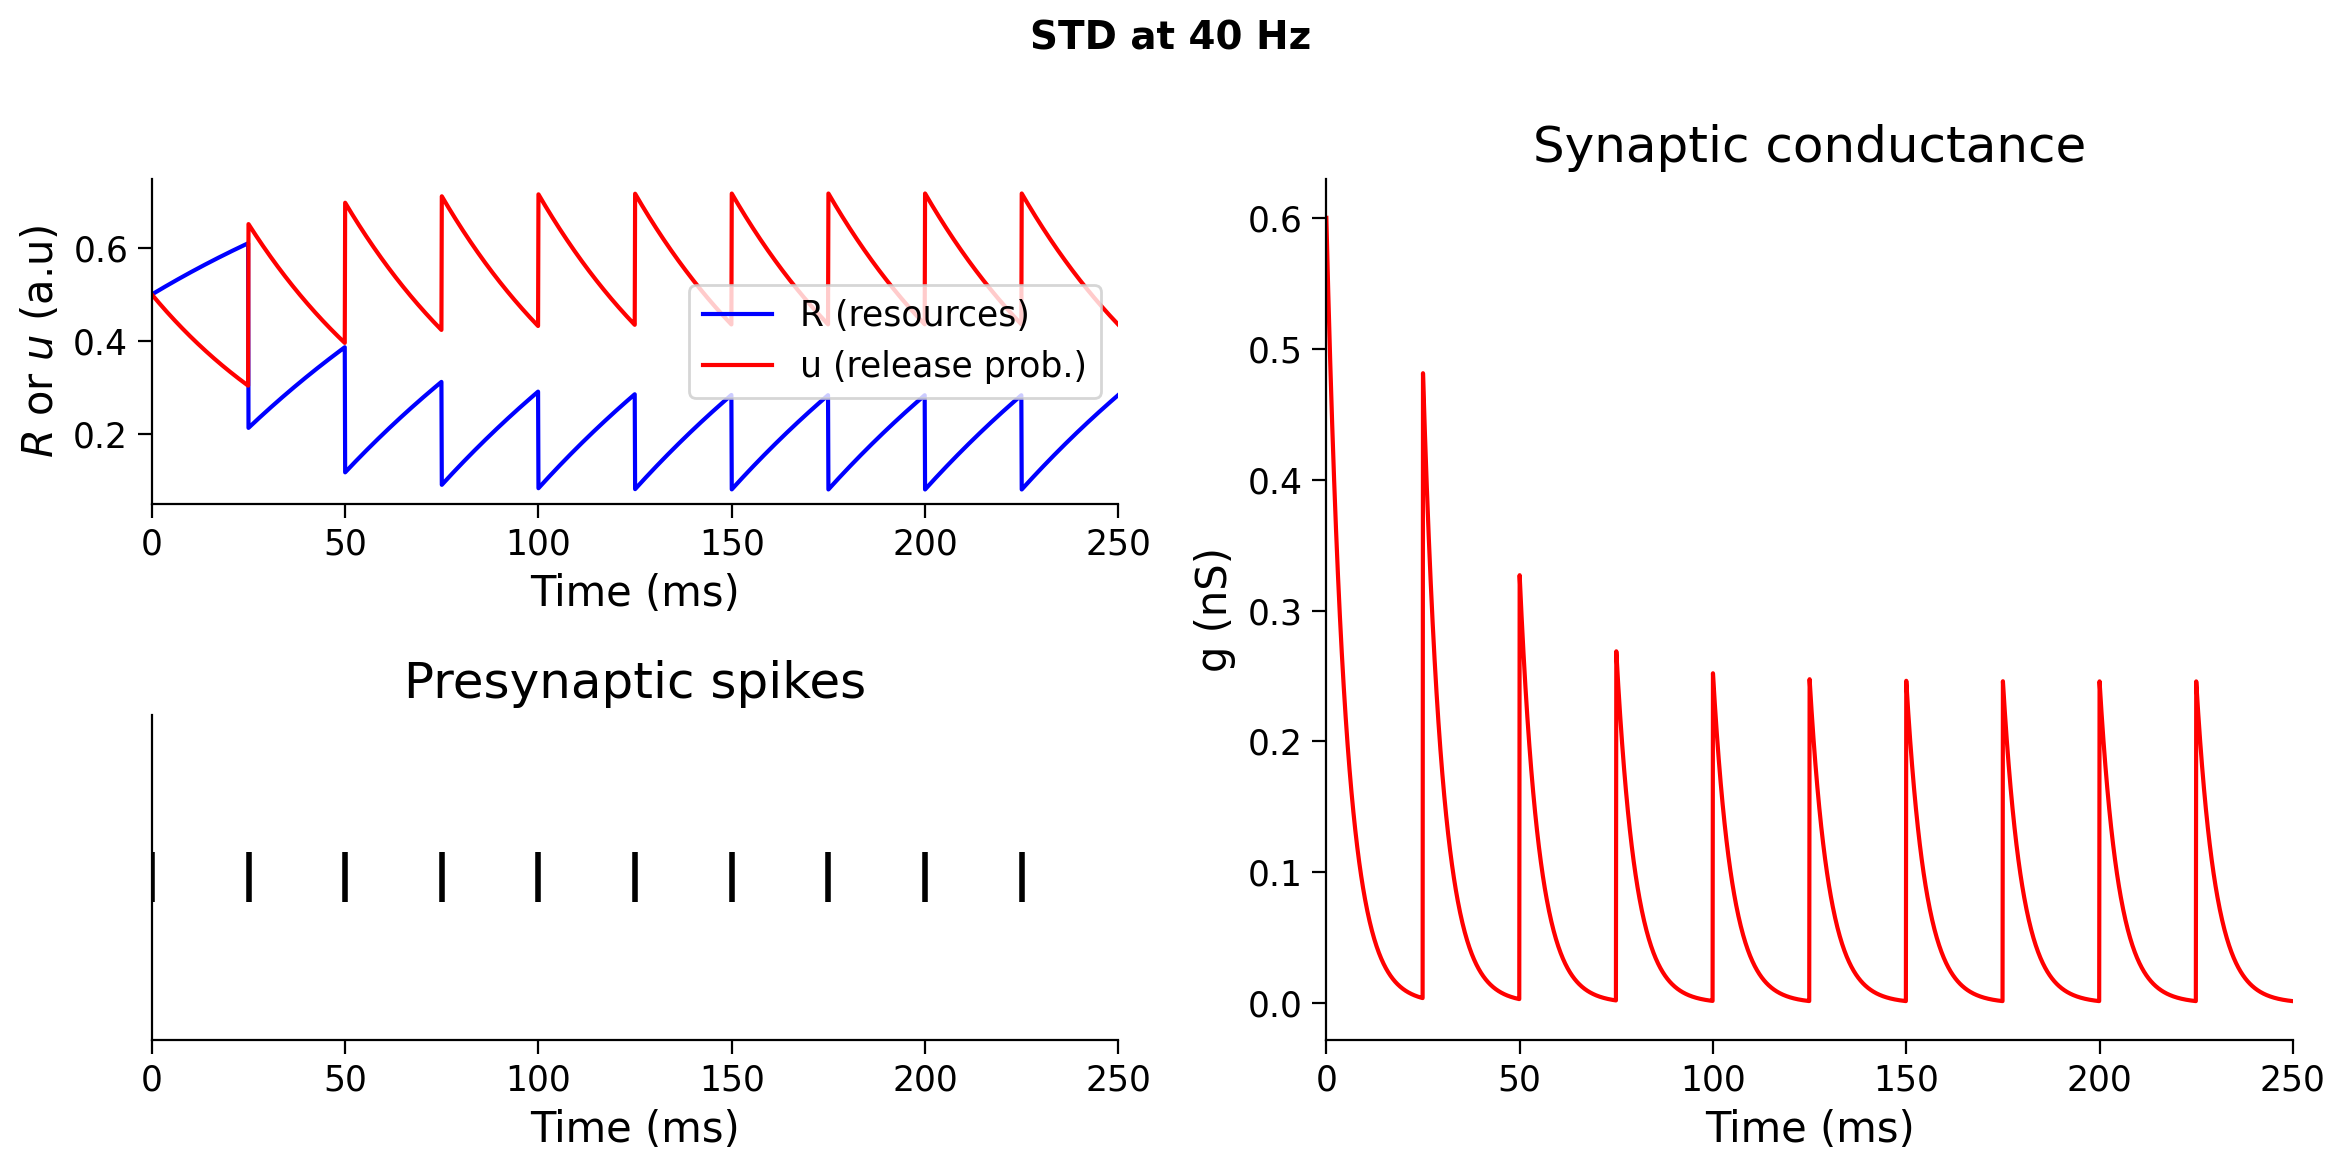

40 Hz: g1=0.4813, g10=0.2459, ratio=0.511


In [5]:
# STD parameters: large U0, tau_d >> tau_f
print("Short-Term Depression (STD)")
print("Parameters: U0=0.5, tau_d=100ms, tau_f=50ms")
print("="*50)

# Low rate
g1, g10 = illustrate_STP(rate=10., U0=0.5, tau_d=100., tau_f=50., 
                         title="STD at 10 Hz")
print(f"10 Hz: g1={g1:.4f}, g10={g10:.4f}, ratio={g10/g1:.3f}")

# High rate
g1, g10 = illustrate_STP(rate=40., U0=0.5, tau_d=100., tau_f=50.,
                         title="STD at 40 Hz")
print(f"40 Hz: g1={g1:.4f}, g10={g10:.4f}, ratio={g10/g1:.3f}")

### Demo: Short-Term Facilitation (STF)

* 跟前面的解釋類似
* 這裡想表達的是在 STF 的情況下，$g$ 的狀態如何，可以看到一開始最高，但之後越來越高(興奮)
* 在頻率變高的時候，興奮更明顯
* 興奮就是 $\tau_f >> \tau_d$


Short-Term Facilitation (STF)
Parameters: U0=0.2, tau_d=100ms, tau_f=750ms


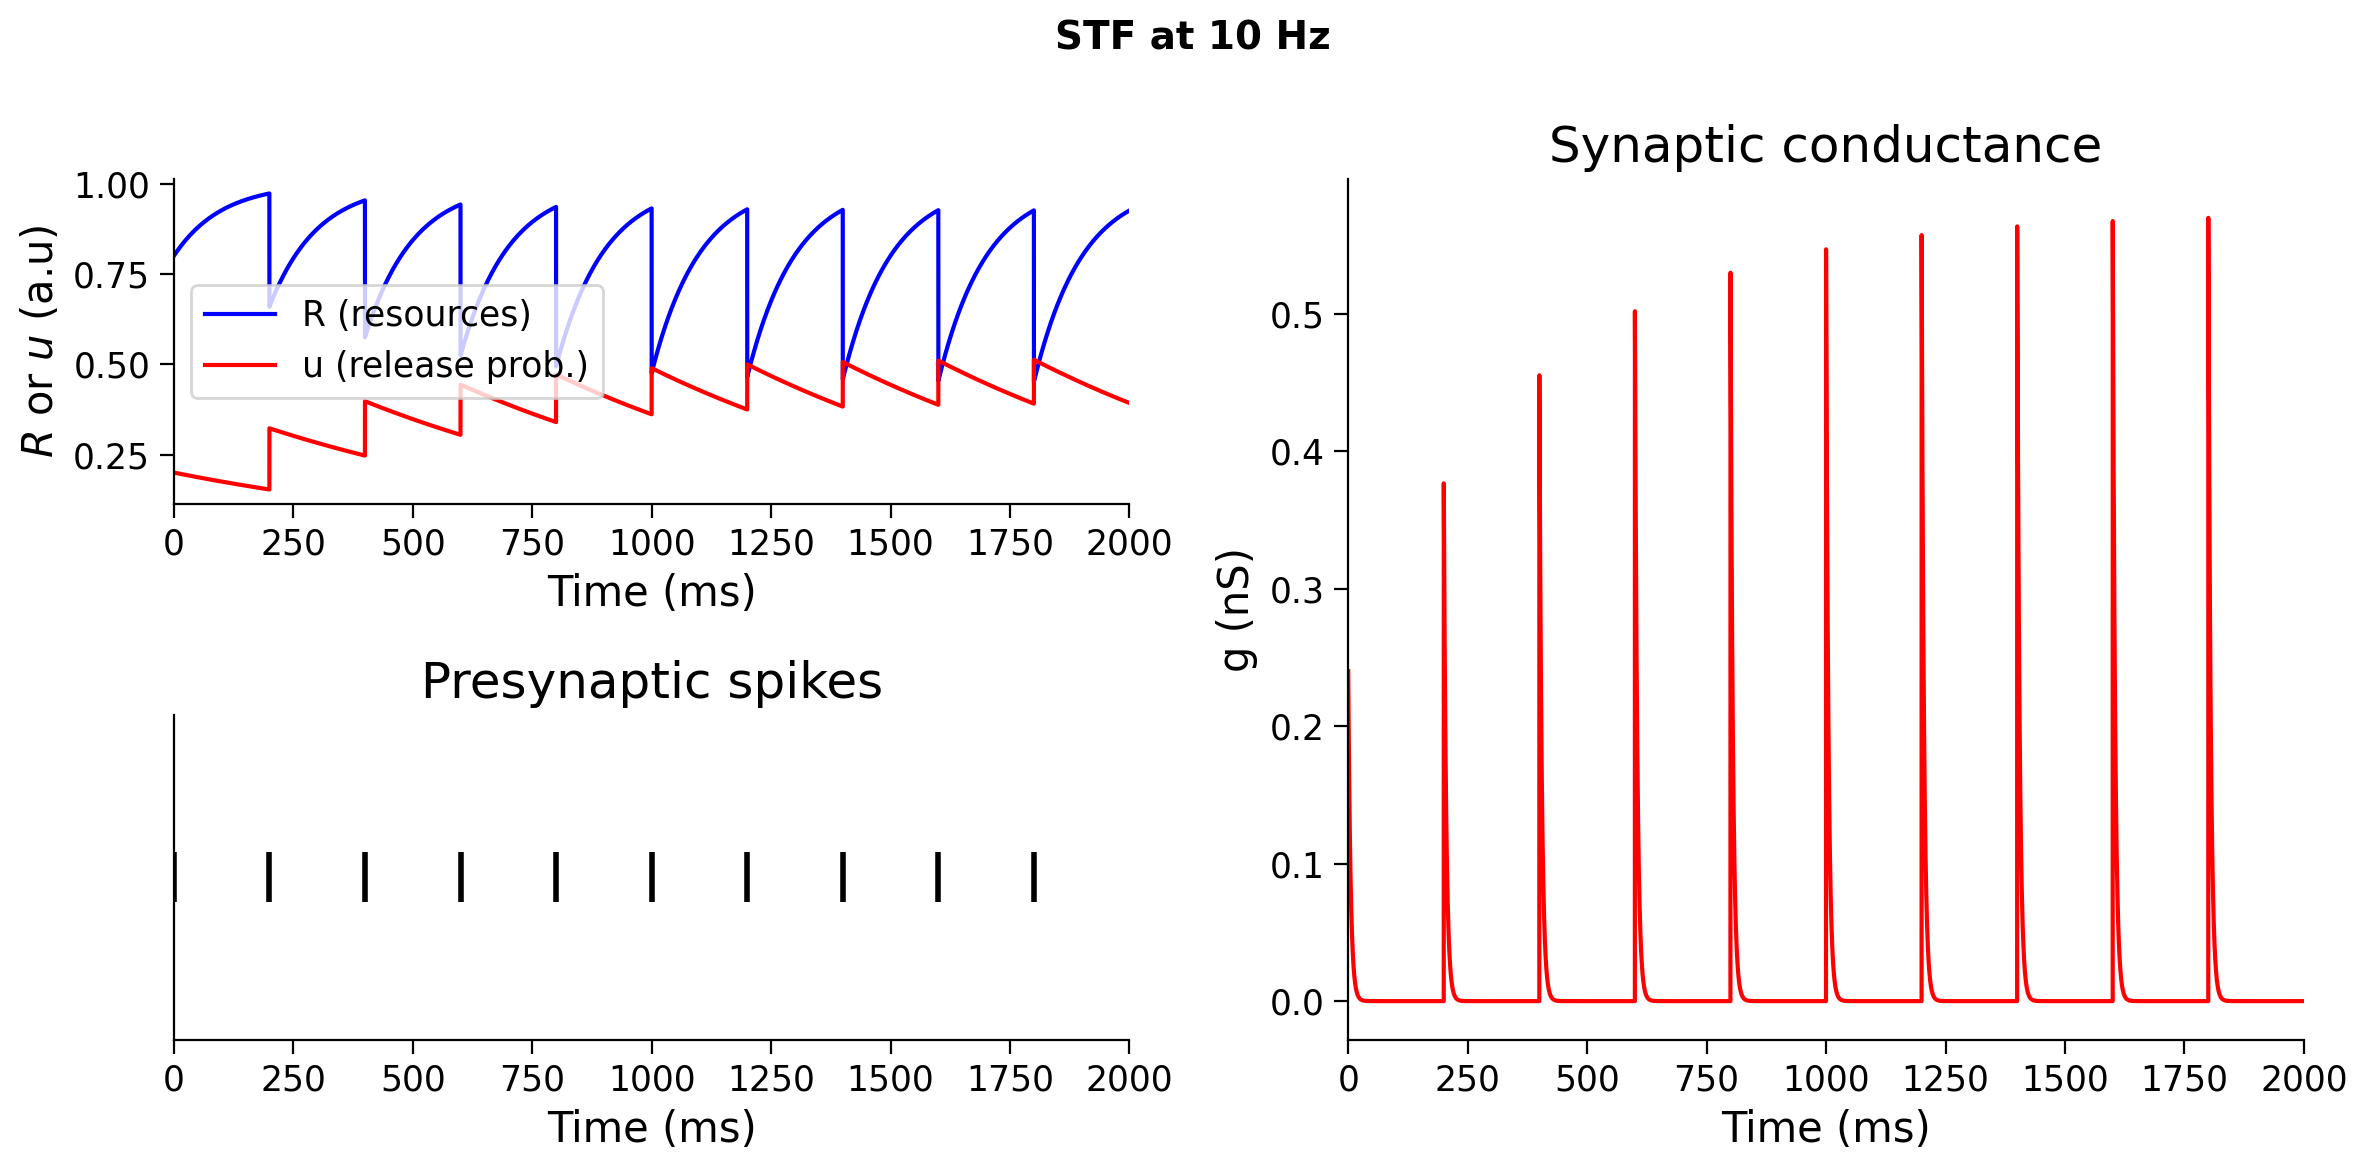

10 Hz: g1=0.3766, g10=0.5697, ratio=1.513


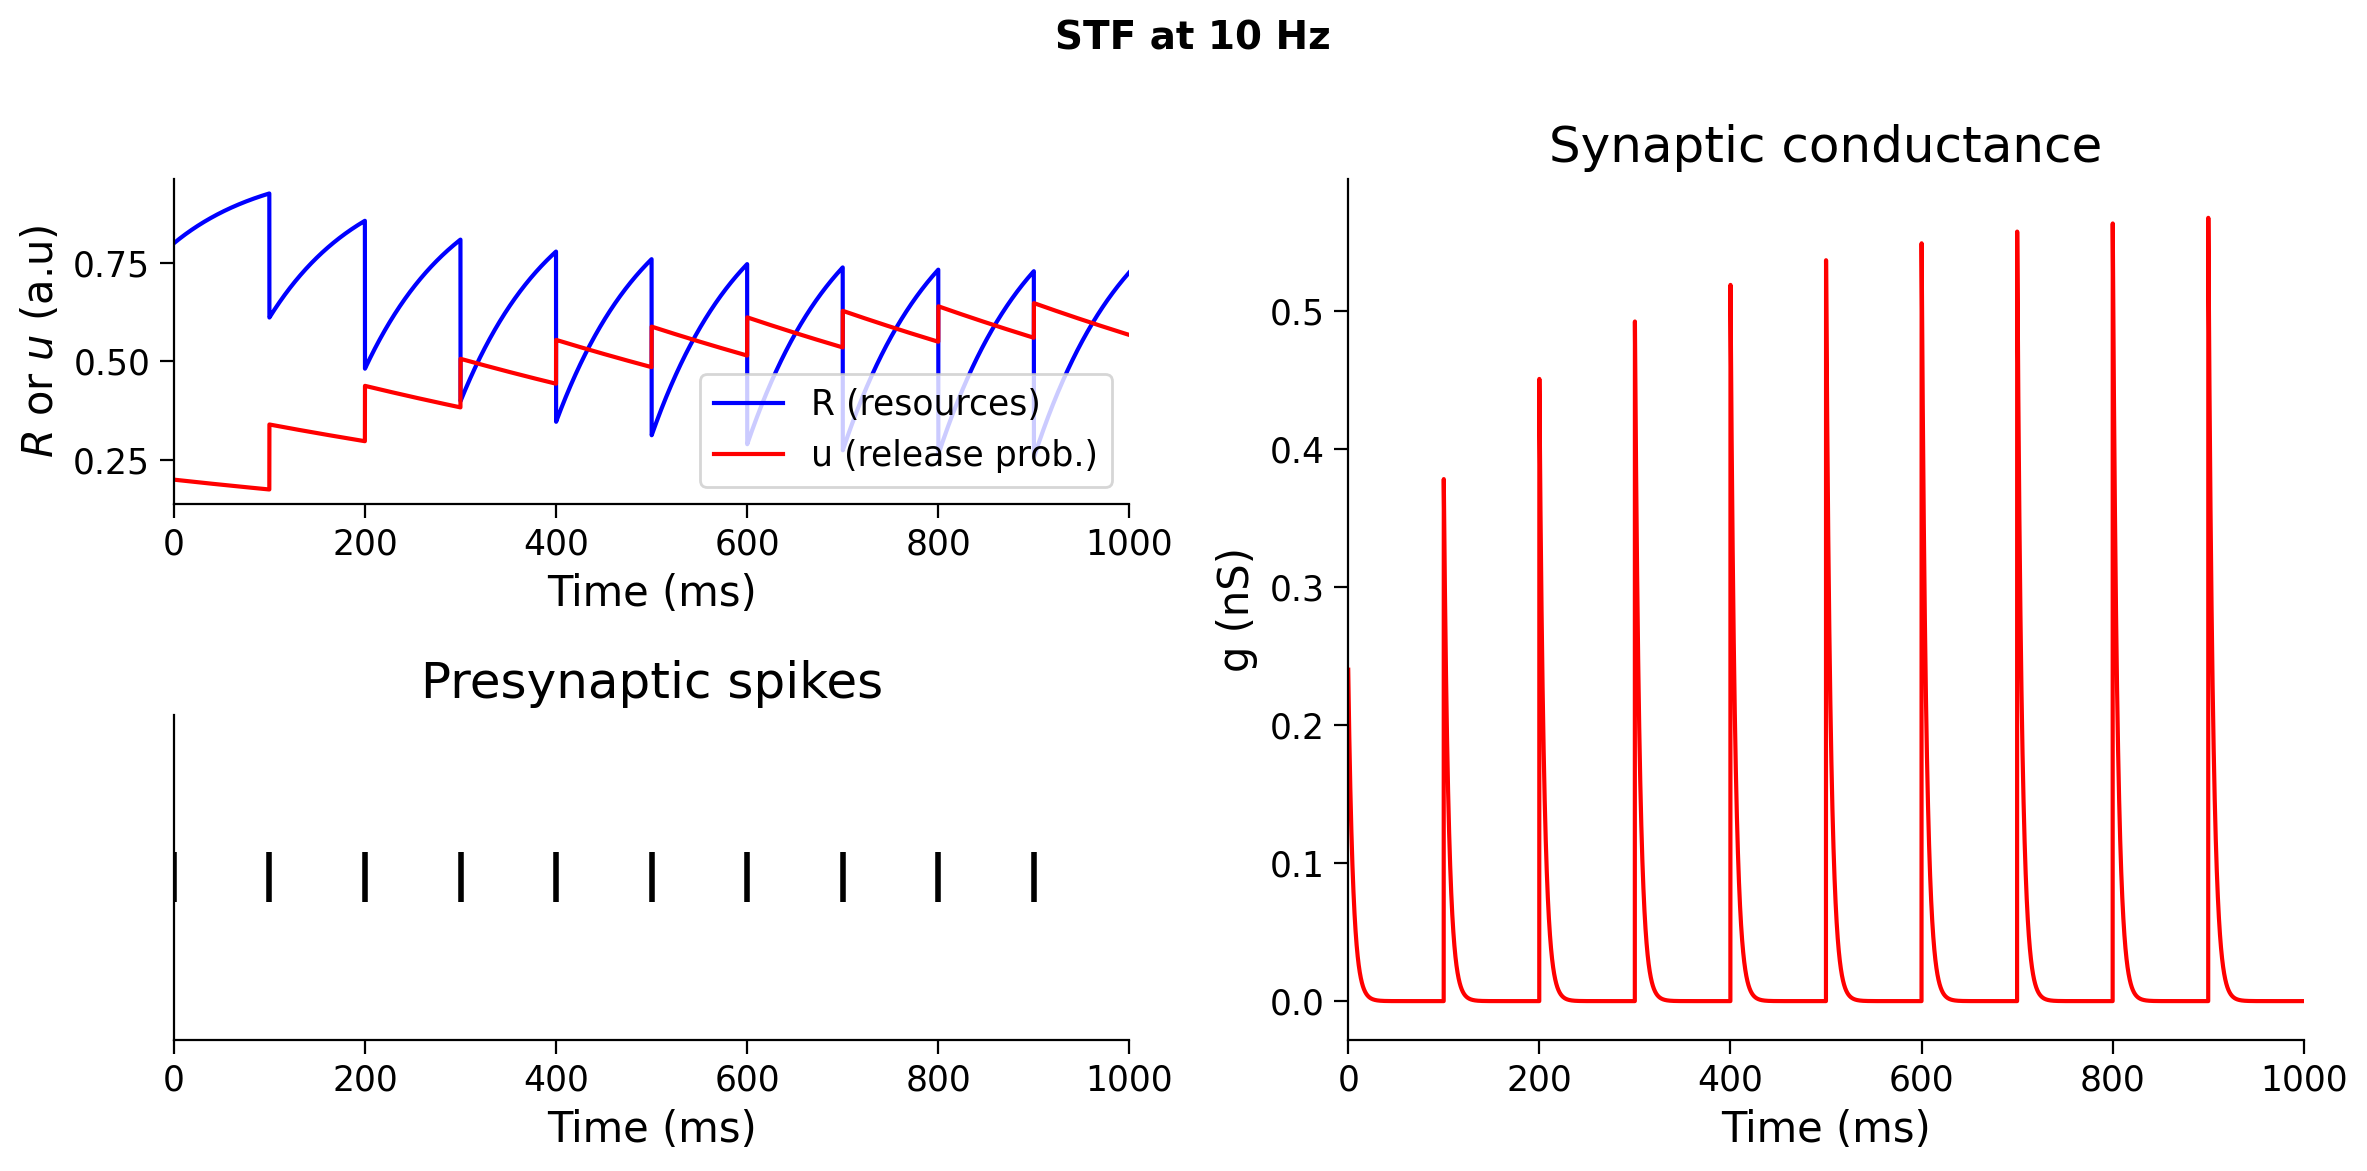

10 Hz: g1=0.3780, g10=0.5672, ratio=1.501


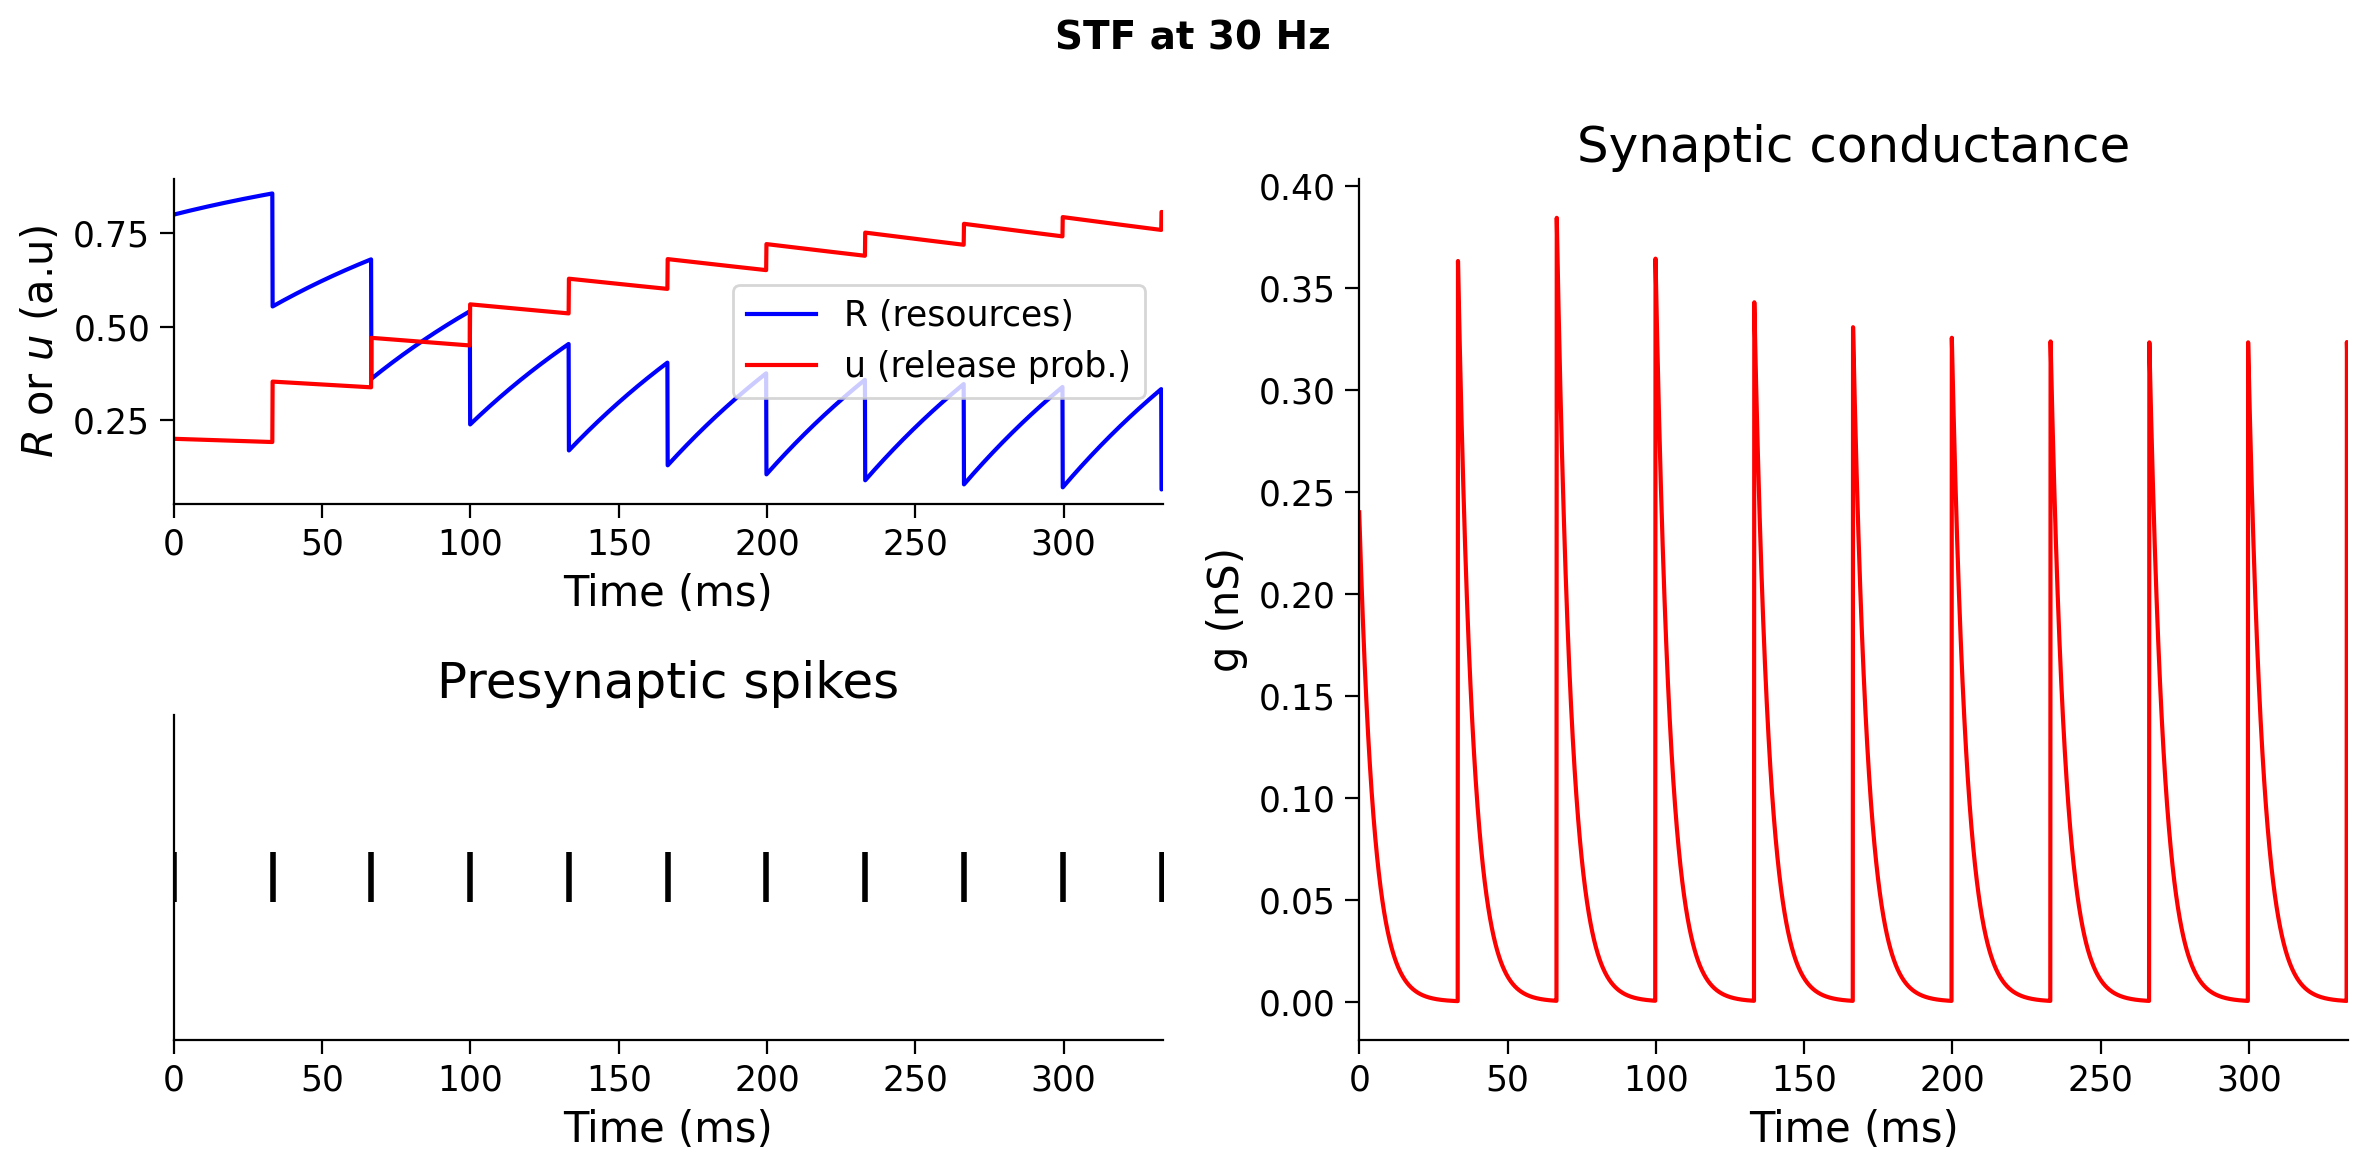

30 Hz: g1=0.3632, g10=0.3233, ratio=0.890


In [6]:
# STF parameters: small U0, tau_f >> tau_d
print("Short-Term Facilitation (STF)")
print("Parameters: U0=0.2, tau_d=100ms, tau_f=750ms")
print("="*50)

# Low rate
g1, g10 = illustrate_STP(rate=5., U0=0.2, tau_d=100., tau_f=750.,
                         title="STF at 10 Hz")
print(f"10 Hz: g1={g1:.4f}, g10={g10:.4f}, ratio={g10/g1:.3f}")


g1, g10 = illustrate_STP(rate=10., U0=0.2, tau_d=100., tau_f=750.,
                         title="STF at 10 Hz")
print(f"10 Hz: g1={g1:.4f}, g10={g10:.4f}, ratio={g10/g1:.3f}")

# High rate
g1, g10 = illustrate_STP(rate=30., U0=0.2, tau_d=100., tau_f=750.,
                         title="STF at 30 Hz")
print(f"30 Hz: g1={g1:.4f}, g10={g10:.4f}, ratio={g10/g1:.3f}")

### STD & STF 結論

STD 的部分沒問題，算直觀

問題在 STF
* 第一張圖給出的就是優秀的平衡狀態，有順利 STF
* 第二章圖前面高，後面弱掉了

---

* $u$ 是瞬間提升(看波形是瞬間拉高)
* $R$ 是慢速的提升(看波形是緩升)
    * **因此 spike 過快，就會導致消耗快**
    * **消耗過快又會導致難以補回來**
* $g$ 是結算，看 $u, R$ 的乘積決定成長量

---

結論: 因此高頻很容易就導致抑制，(即使 $\tau_f >> \tau_d$)，除非有非常極端的參數

### Compare STD vs STF across firing rates

這裡更直觀的應驗前面提到的結論

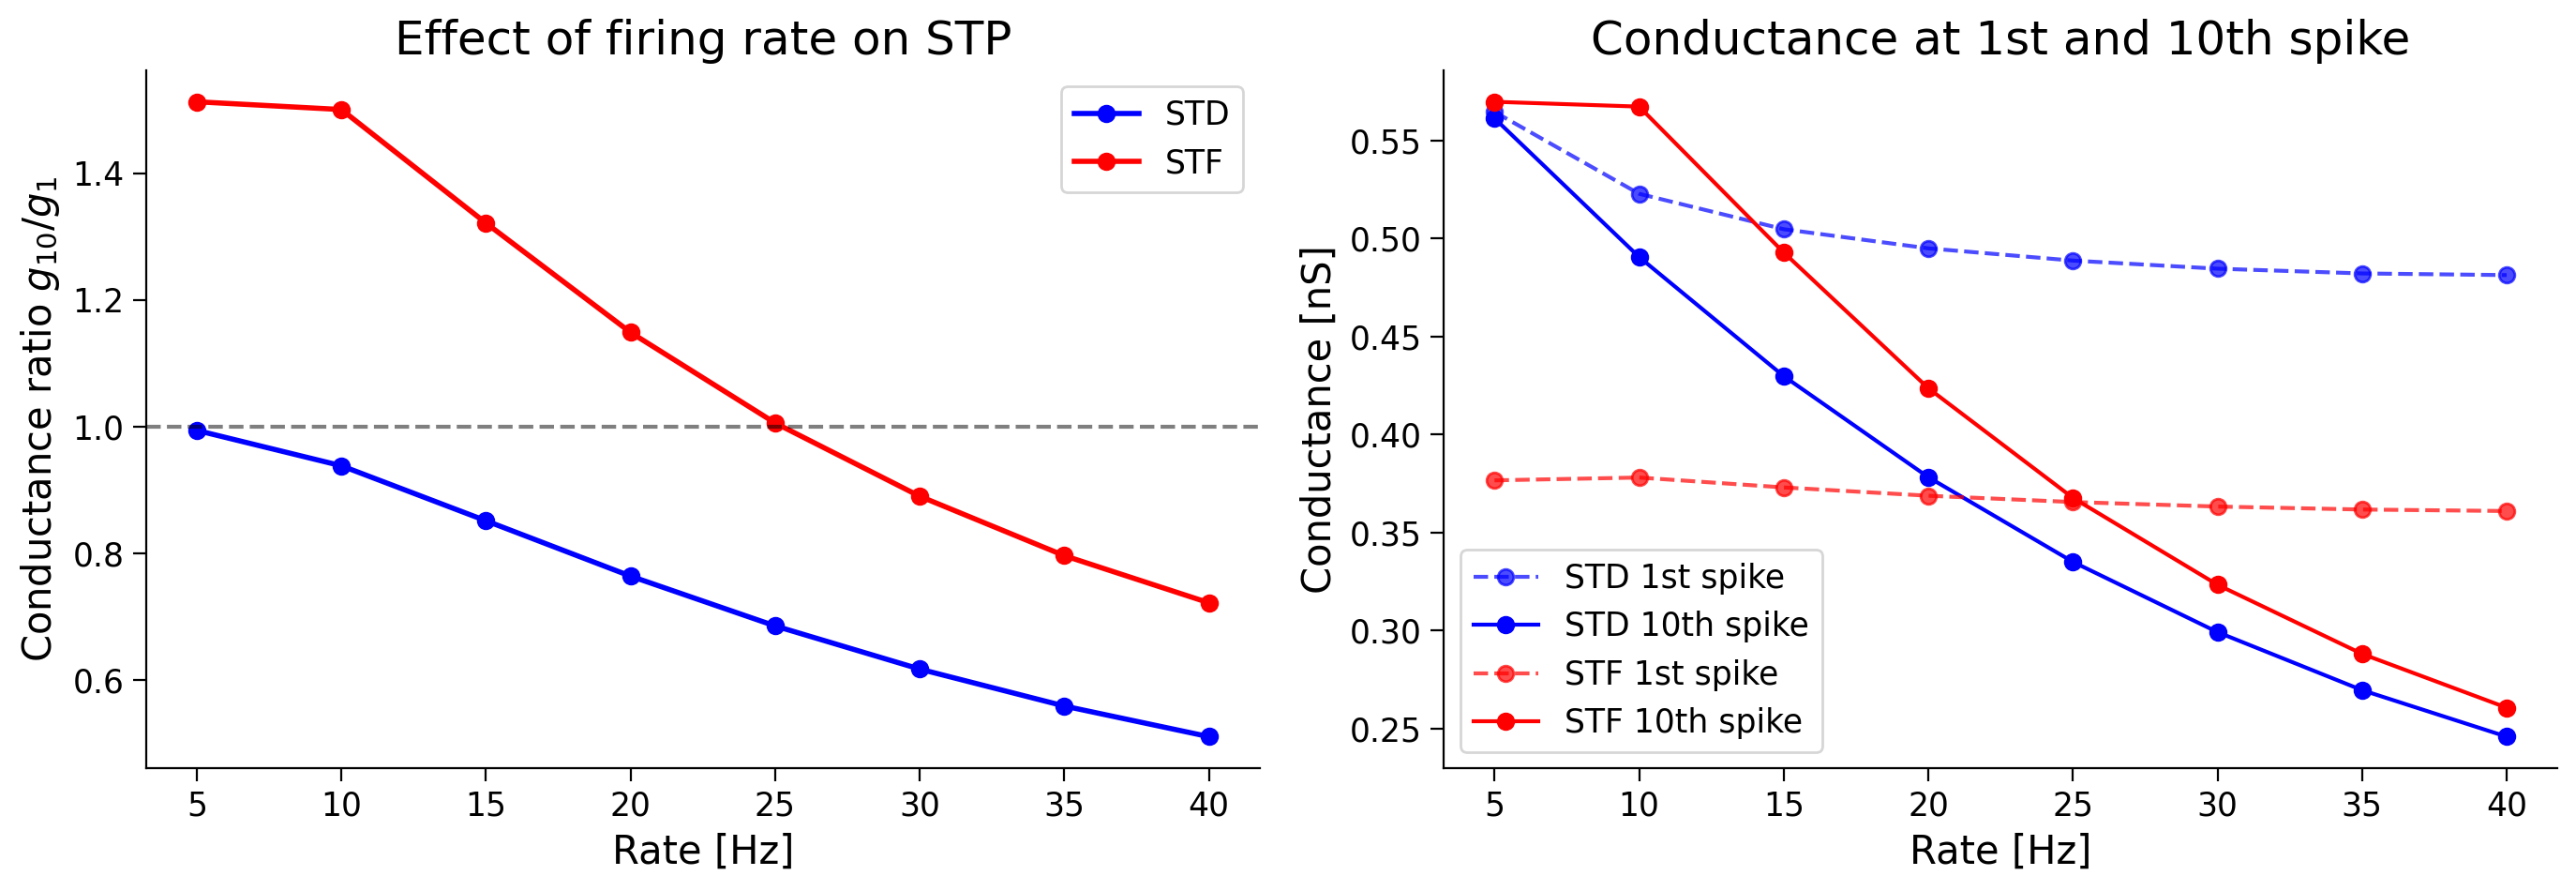

In [7]:
def compute_stp_ratio(U0, tau_d, tau_f, rates):
    """Compute the ratio of 10th to 1st spike conductance for different rates."""
    g_1 = np.zeros(len(rates))
    g_10 = np.zeros(len(rates))

    for ii, rate in enumerate(rates):
        T_simu = 10.0 * 1000 / rate
        pars = default_pars(T=T_simu)
        dt = pars['dt']

        isi_num = int((1e3/rate)/dt)
        pre_spike_train = np.zeros(len(pars['range_t']))
        pre_spike_train[::isi_num] = 1.

        _, _, g = dynamic_syn(g_bar=1.2, tau_syn=5., U0=U0,
                              tau_d=tau_d, tau_f=tau_f,
                              pre_spike_train=pre_spike_train,
                              dt=dt)
        g_1[ii] = g[isi_num]
        g_10[ii] = g[9*isi_num]

    return g_1, g_10


# Compare STD and STF
rates = np.arange(5., 40.1, 5.)

# STD
g1_std, g10_std = compute_stp_ratio(U0=0.5, tau_d=100., tau_f=50., rates=rates)

# STF
g1_stf, g10_stf = compute_stp_ratio(U0=0.2, tau_d=100., tau_f=750., rates=rates)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rates, g10_std / g1_std, 'b-o', label='STD', linewidth=2)
axes[0].plot(rates, g10_stf / g1_stf, 'r-o', label='STF', linewidth=2)
axes[0].axhline(1.0, color='k', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Rate [Hz]')
axes[0].set_ylabel(r'Conductance ratio $g_{10}/g_{1}$')
axes[0].legend()
axes[0].set_title('Effect of firing rate on STP')

axes[1].plot(rates, g1_std, 'b--o', label='STD 1st spike', alpha=0.7)
axes[1].plot(rates, g10_std, 'b-o', label='STD 10th spike')
axes[1].plot(rates, g1_stf, 'r--o', label='STF 1st spike', alpha=0.7)
axes[1].plot(rates, g10_stf, 'r-o', label='STF 10th spike')
axes[1].set_xlabel('Rate [Hz]')
axes[1].set_ylabel('Conductance [nS]')
axes[1].legend()
axes[1].set_title('Conductance at 1st and 10th spike')

plt.tight_layout()
plt.show()

# Part 2: Spike-Timing Dependent Plasticity (STDP)

<font size=6>
注意這裡再講的東西跟前面的 STP/STD 有差異，這裡是 突觸後神經元 (Post) 接收到 spike 後，突觸後樹突的行為
</font>

## Section 3.1: STDP Model

**STDP**: 
* 假設前級神經元打出 spike 後，後級神經元接著打出 spike，表示兩者是有關連的，會加強突觸權重
* 後級神經元先打出 spike，前級神經元才打出 spike，這表示前後無關，所以減弱突觸權重

---

具體的生物原理是 `NMDA 受體` 的物理阻塞效應

NMDA 是一個離子通道，需要符合兩個條件
1. 麩胺酸結合到 NMDA 受體上
2. 卡住通道的 $Mg^{2+}$ 被 spike 的高壓踹出去

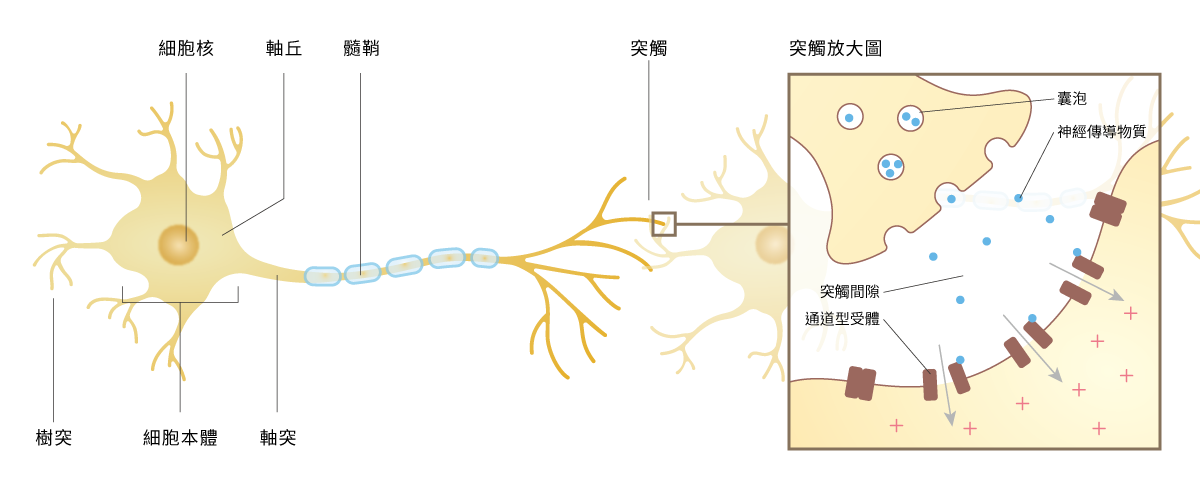

* LTP
    1. Pre spike 神經傳導物質麩胺酸插到 NMDA，但是通道還沒打開
    2. Post spike 
        * 注意是軸丘發 spike
            * 往前送給軸突，軸突有不應期所以不會倒灌
            * 往後倒灌 (bAP) 給細胞本體 & 樹突，樹突上的 NMDA 的 $Mg^{2+}$ 被這股正電(同性相斥) 踹掉
        * 因此達成兩個條件了，通道打開，$Ca^{2+}$ 湧入\
          喚醒了 (激酶 Kinase) 去安裝更多 AMPA 受體(只讓 $Na^+$) 進來，突觸變強了!
          別和突觸前末梢的 VGCC 搞混了!

* LTD
    1. Post spike
        1. bAP 來踹走 $Mg^{2+}$，但是 Pre 沒有 spike，因此 NMDA 通道不開，後續 $Mg^{2+}$ 也黏回去了
        2. Pre spike 後到，但是 NMDA 沒滿足條件，此時只會有極少量的 $Ca^{2+}$ 湧入
            * 這裡別和前面 (STP/STD) 突觸前末梢的機制搞混了!
            * 極少的 $Ca^{2+}$ 反而會對 (磷酸酶 Phosphatase) 有利，他們會去拆掉通道

怎麼偵測 $Ca^{2+}$ 的量 ?
* 通道建設組: 難以喚醒，但能力強
* 通道拆除組: 好喚醒，但能力弱
* 因此實際上 LTP 也會叫醒通道拆除組，但通道建設組太強了蓋過去了

### STDP 規則

$$\Delta W = \begin{cases}
A_+ e^{(t_{pre}-t_{post})/\tau_+} & \text{if } t_{post} > t_{pre} \text{ (LTP)}\\
-A_- e^{-(t_{pre}-t_{post})/\tau_-} & \text{if } t_{post} < t_{pre} \text{ (LTD)}
\end{cases}$$

- 突觸前 spike **在** 突觸後 spike **之前** → **Long-Term Potentiation (LTP)**
- 突觸前 spike **在** 突觸後 spike **之後** → **Long-Term Depression (LTD)**

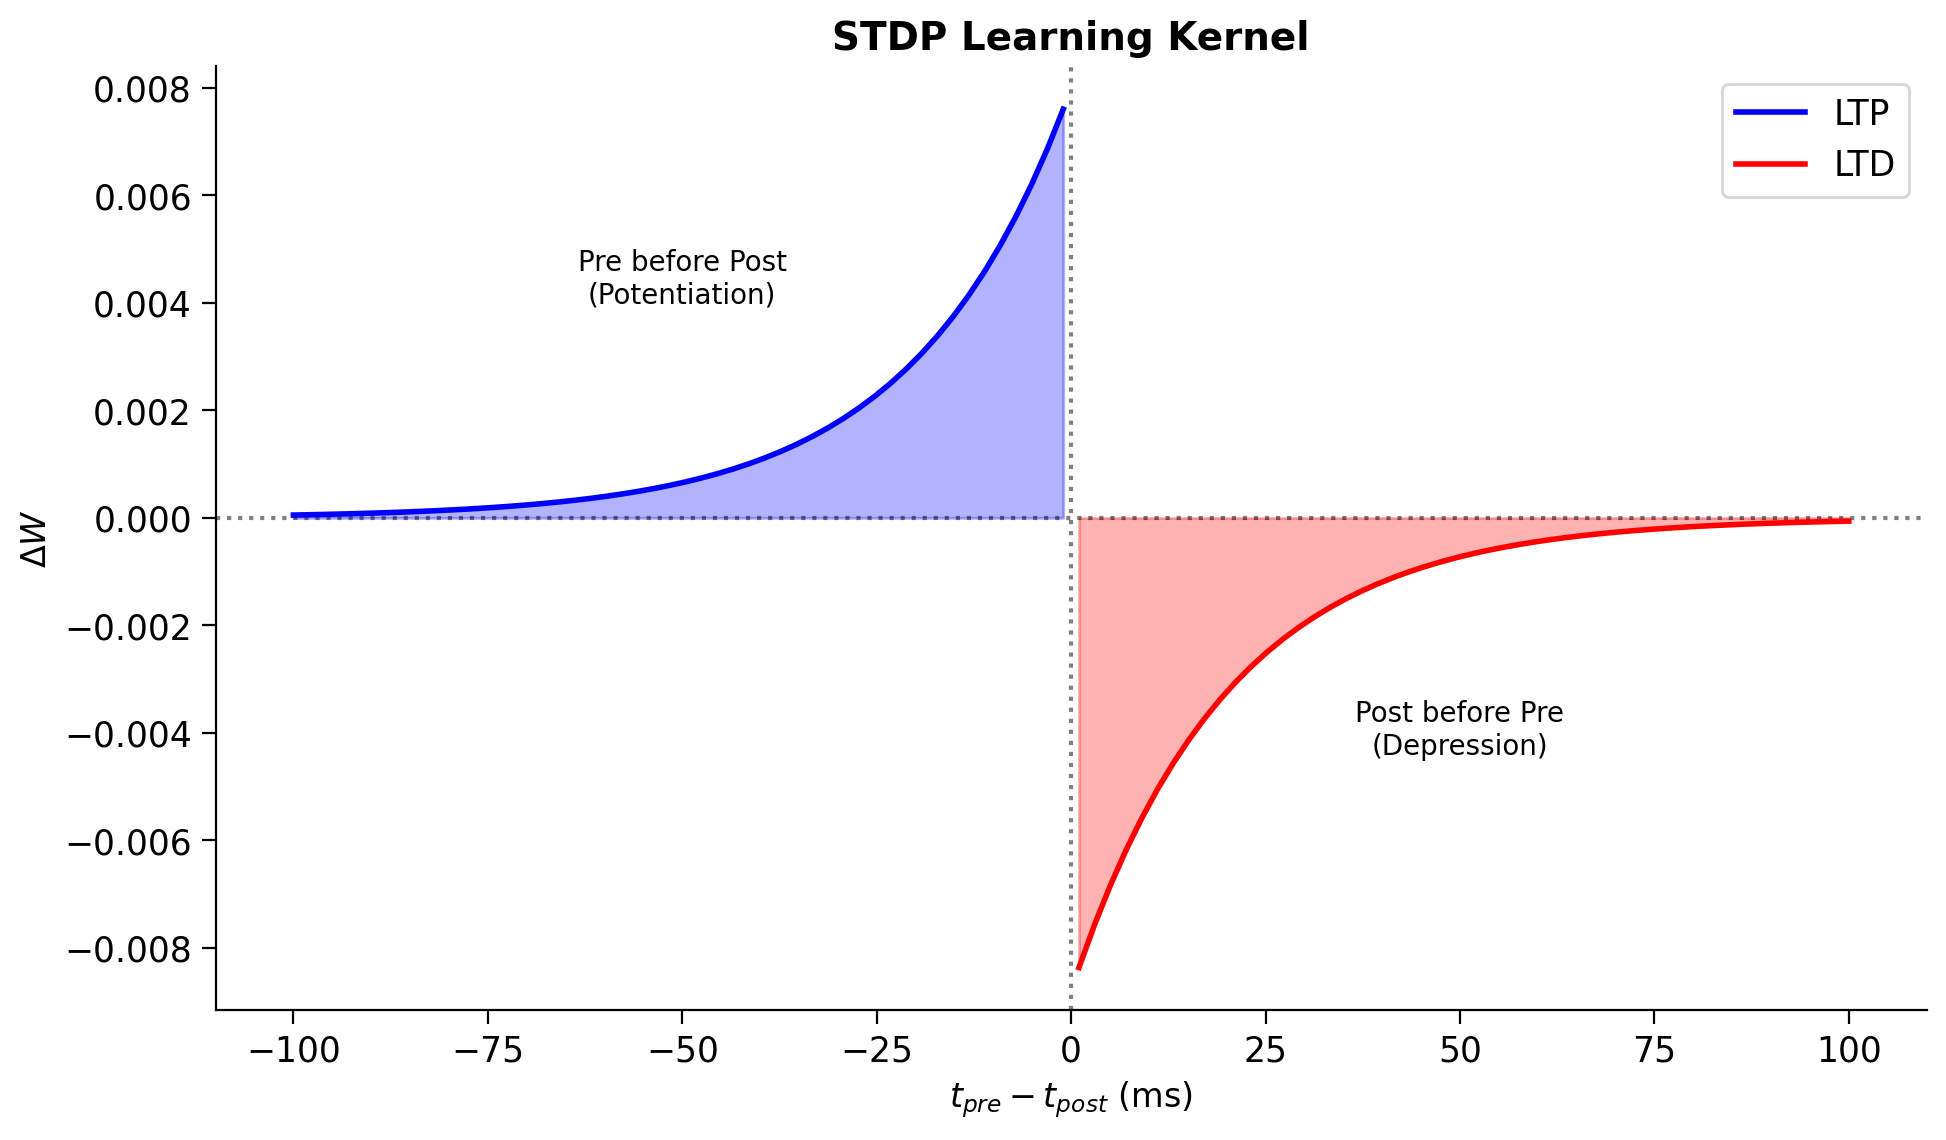

In [8]:
# Plot STDP kernel
pars = default_pars_STDP()
plot_STDP_kernel(pars['A_plus'], pars['A_minus'], pars['tau_stdp'])

### 補充多 spike 情況

前面在討論兩個 spike 的情況，問題是實際上會有很多個 spike

這也是為甚麼會想要使用 exp 函數

---

假設 `[pre 1, post 1, pre2, post 2]` 而 $post_2 > pre_2 > post_1 > pre_1$\
在 post 2 的時候相對最初始的 $W_0$ 要加上\
$\Delta W_{total} = [A_+ exp(\frac{-|post_1 - pre_1|}{\tau})] - [A_- \exp\left(\frac{-|post_1 - pre_2|}{\tau_-}\right)] + [A_+ exp(\frac{-|post_2 - pre_1|}{\tau}) + A_+ exp(\frac{-|post_2 - pre_2|}{\tau})]$\
不會忽略前面的影響力，而是用指數衰減，但會忽略 $post_2$ 的影響

---

$\Delta W_{total} = \Sigma_{t_{post}} \Sigma_{t_{pre}} \begin{cases}
A_+ exp(\frac{-|t_{post} - t_{pre}|}{\tau_+}), t_{post} > t_{pre}\\
-A_- exp(\frac{-|t_{post} - t_{pre}|}{\tau_-}), t_{post} < t_{pre}
\end{cases}$

假設每次 spike 要更新 $\Delta W$ 都要重算，那肯定是無法接受這計算量

因此後面介紹了 $P, M$ 優化這個算法，本質上是去紀錄狀態 & 動態更新 W

## Section 3.2: Tracking Pre- and Postsynaptic Spikes

為了實現 STDP，我們需要追蹤 spike 時間。使用指數衰減的 trace 變數：

### 突觸後 trace $M(t)$:
$$\tau_- \frac{dM}{dt} = -M$$

當突觸後神經元 spike 時：$M(t) = M(t) - A_-$

### 突觸前 trace $P(t)$:
$$\tau_+ \frac{dP}{dt} = -P$$

當突觸前神經元 spike 時：$P(t) = P(t) + A_+$

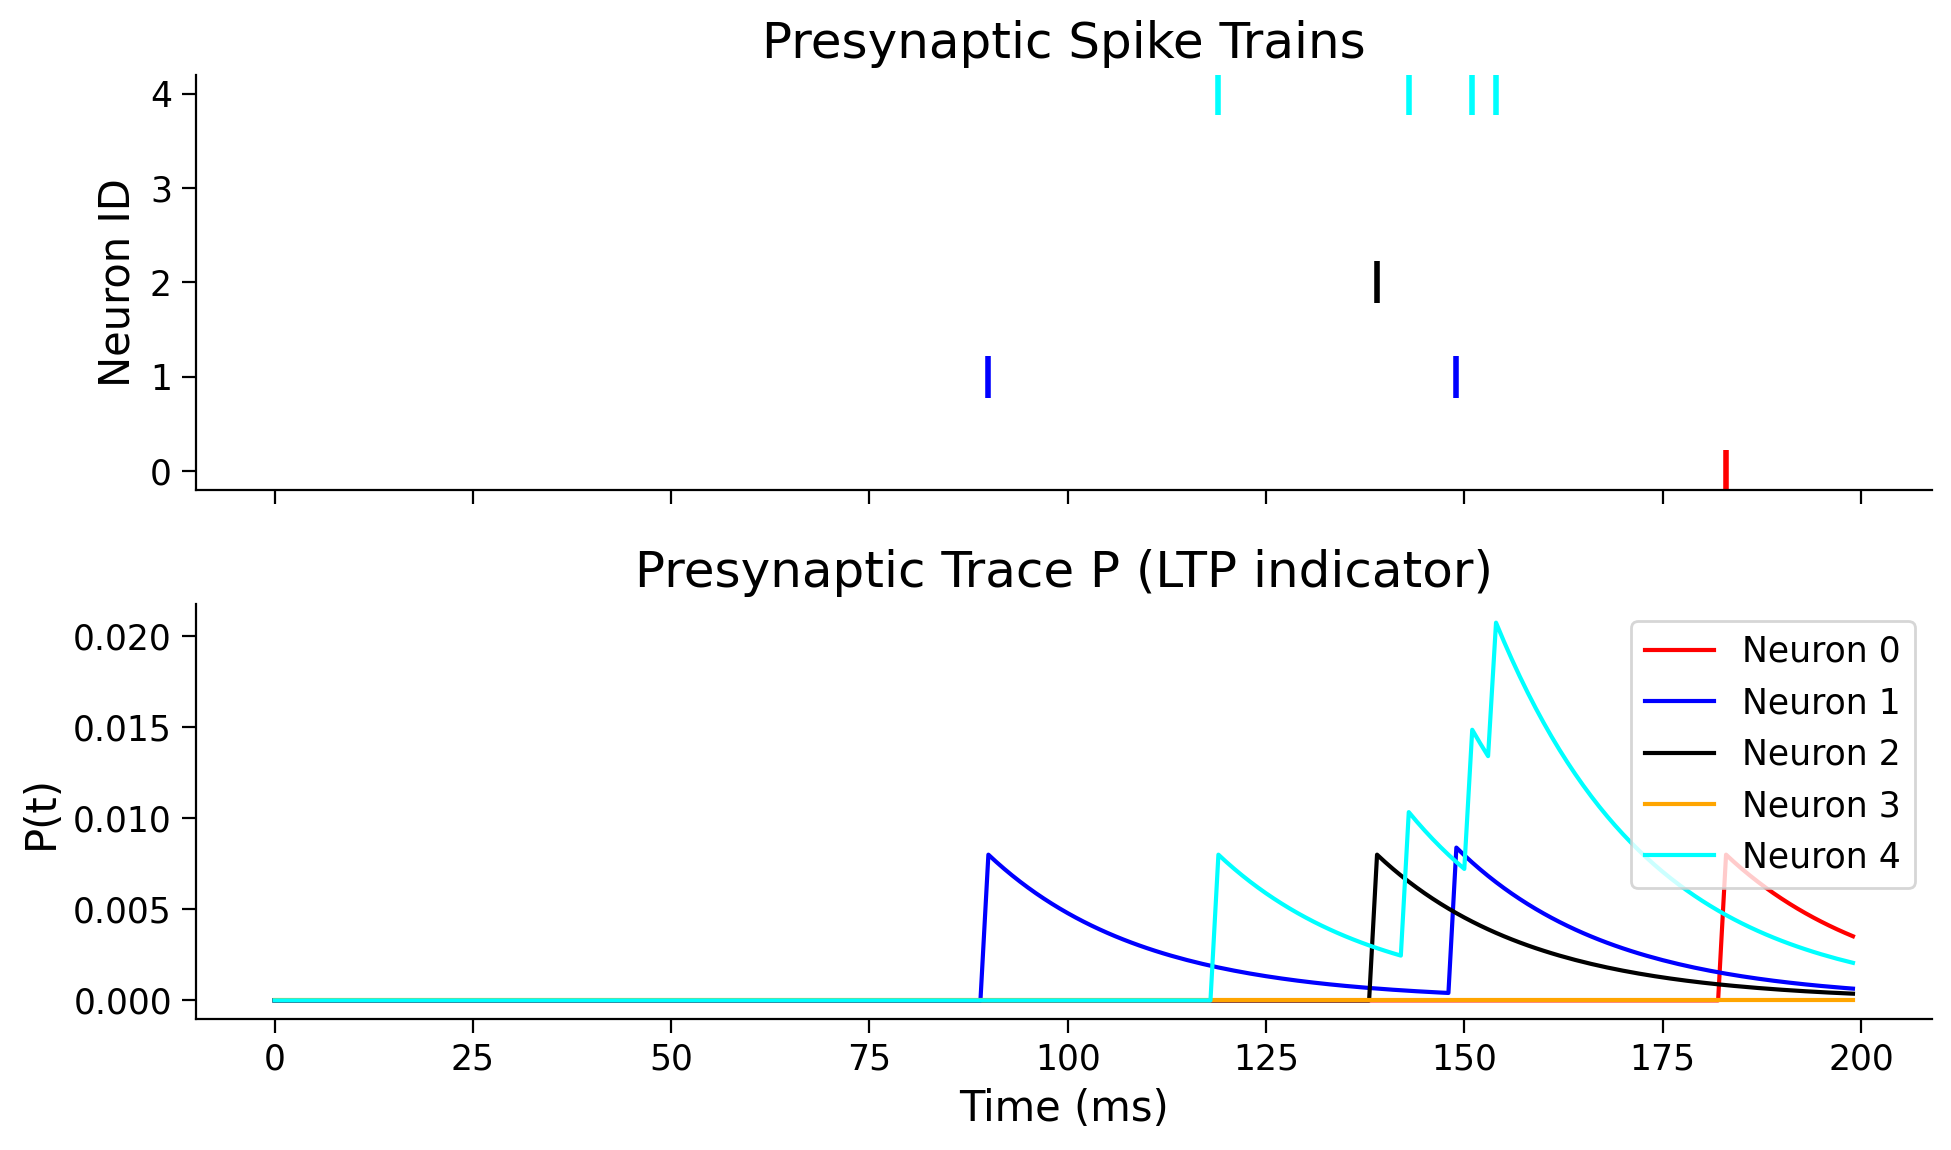

In [9]:
# Visualize presynaptic trace P
pars = default_pars_STDP(T=200., dt=1.)
pre_spike_train_ex = Poisson_generator(pars, rate=10, n=5, myseed=2020)
P = generate_P(pars, pre_spike_train_ex)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

color_set = ['red', 'blue', 'black', 'orange', 'cyan']

# Raster plot
for i in range(5):
    t_sp = pars['range_t'][pre_spike_train_ex[i, :] > 0.5]
    axes[0].plot(t_sp, i * np.ones(len(t_sp)), '|', color=color_set[i],
                 ms=15, markeredgewidth=2)
axes[0].set_ylabel('Neuron ID')
axes[0].set_title('Presynaptic Spike Trains')

# P trace
for k in range(5):
    axes[1].plot(pars['range_t'], P[k, :], color=color_set[k], lw=1.5, label=f'Neuron {k}')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('P(t)')
axes[1].set_title('Presynaptic Trace P (LTP indicator)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## Section 3.3: LIF Neuron with STDP Synapses

突觸權重更新規則：

- 當第 $i$ 個突觸前神經元 spike 時：
$$\bar{g}_i = \bar{g}_i + M(t) \cdot \bar{g}_{max}$$

- 當突觸後神經元 spike 時：
$$\bar{g}_i = \bar{g}_i + P_i(t) \cdot \bar{g}_{max}, \quad \forall i$$

**注意**: `run_LIF_cond_STDP()` 使用混合方法實現，結合 NumPy 用於 STDP 靈活性。

### Demo: STDP Weight Evolution

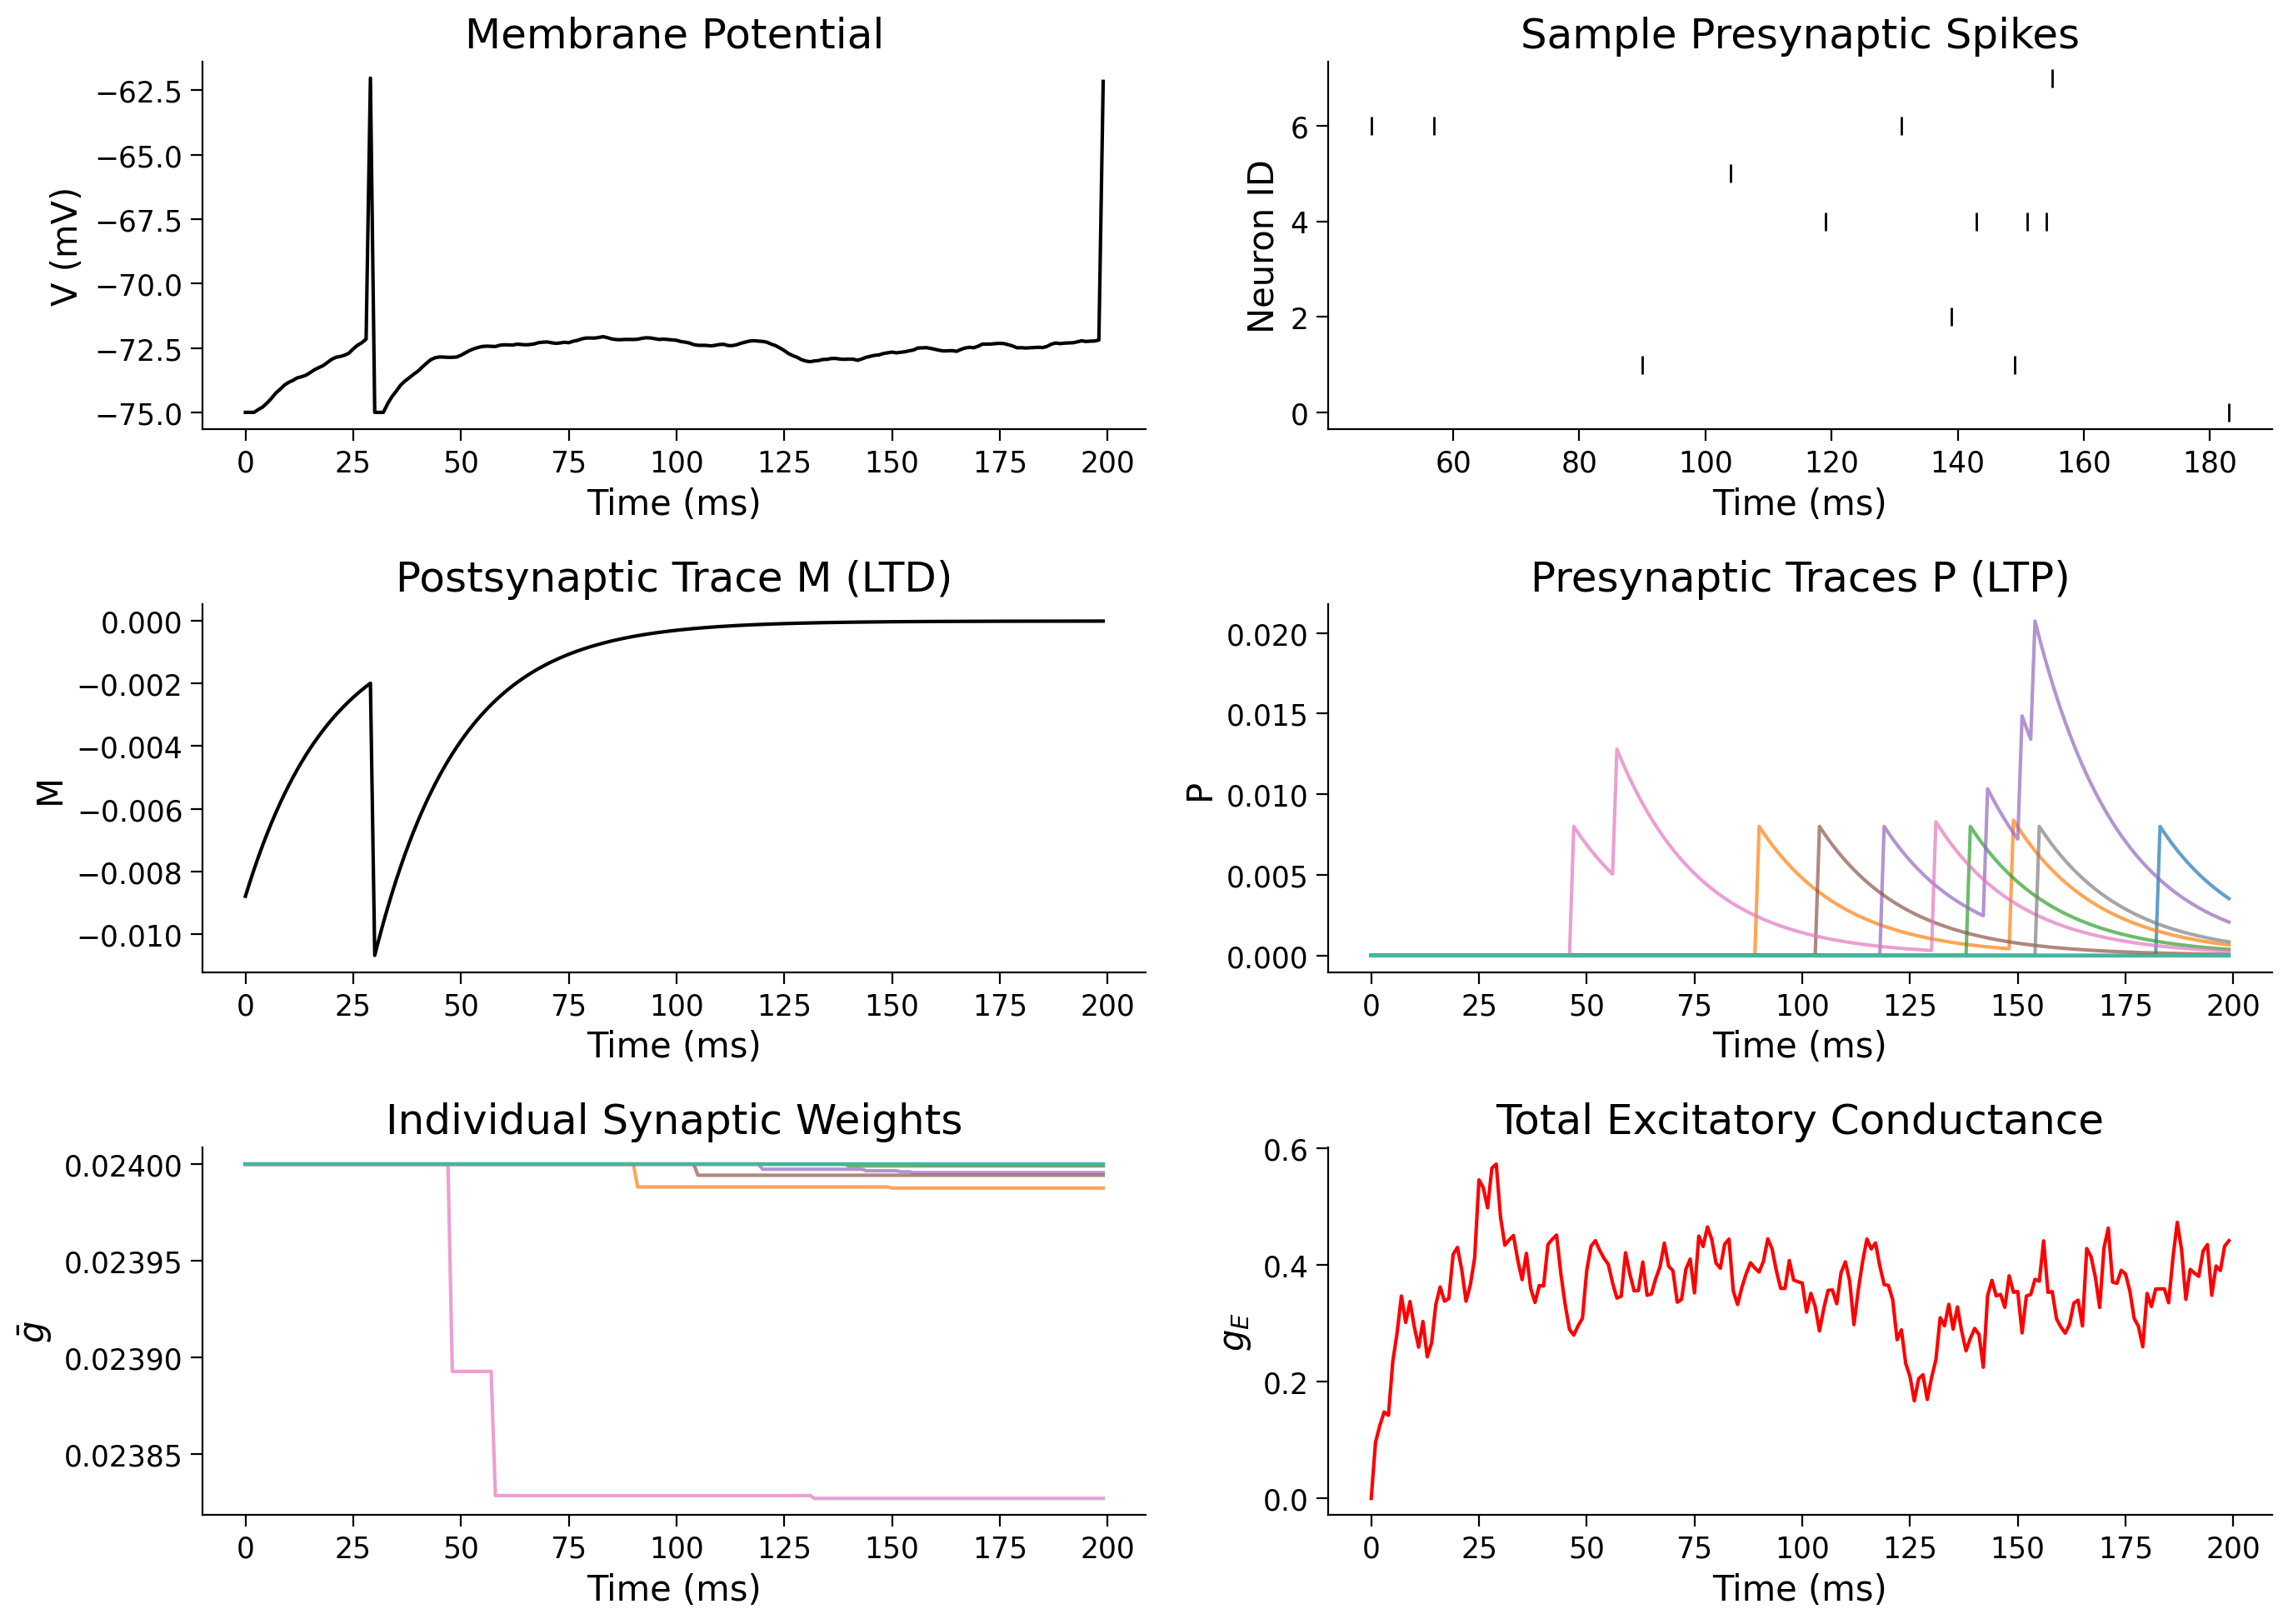

In [10]:
# Set up parameters
pars = default_pars_STDP(T=200., dt=1.)
pars['gE_bar'] = 0.024       # max synaptic conductance
pars['gE_init'] = 0.024      # initial synaptic conductance
pars['VE'] = 0.              # [mV] reversal potential
pars['tau_syn_E'] = 5.       # [ms] EPSP time constant
pars["V_th"] = -72
# Generate Poisson spike trains
pre_spike_train_ex = Poisson_generator(pars, rate=10, n=300, myseed=2020)

# Simulate with STDP
v, rec_spikes, gE, P, M, gE_bar_update = run_LIF_cond_STDP(pars, pre_spike_train_ex)

# Plot results
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Membrane potential
dt, range_t = pars['dt'], pars['range_t']
v_plot = v.copy()
if rec_spikes.size:
    sp_num = (rec_spikes / dt).astype(int) - 1
    sp_num = sp_num[sp_num < len(v_plot)]
    v_plot[sp_num] += 10
axes[0, 0].plot(range_t, v_plot, 'k')
axes[0, 0].set_xlabel('Time (ms)')
axes[0, 0].set_ylabel('V (mV)')
axes[0, 0].set_title('Membrane Potential')

# Raster plot
for i in range(10):
    t_sp = range_t[pre_spike_train_ex[i, :] > 0.5]
    if len(t_sp) > 0:
        axes[0, 1].plot(t_sp, i * np.ones(len(t_sp)), 'k|', ms=8, markeredgewidth=1)
axes[0, 1].set_xlabel('Time (ms)')
axes[0, 1].set_ylabel('Neuron ID')
axes[0, 1].set_title('Sample Presynaptic Spikes')

# M trace (postsynaptic)
axes[1, 0].plot(range_t, M, 'k')
axes[1, 0].set_xlabel('Time (ms)')
axes[1, 0].set_ylabel('M')
axes[1, 0].set_title('Postsynaptic Trace M (LTD)')

# P traces (presynaptic)
for i in range(10):
    axes[1, 1].plot(range_t, P[i, :], alpha=0.7)
axes[1, 1].set_xlabel('Time (ms)')
axes[1, 1].set_ylabel('P')
axes[1, 1].set_title('Presynaptic Traces P (LTP)')

# Synaptic weights
for i in range(10):
    axes[2, 0].plot(range_t, gE_bar_update[i, :], alpha=0.7)
axes[2, 0].set_xlabel('Time (ms)')
axes[2, 0].set_ylabel(r'$\bar{g}$')
axes[2, 0].set_title('Individual Synaptic Weights')

# Total conductance
axes[2, 1].plot(range_t, gE, 'r')
axes[2, 1].set_xlabel('Time (ms)')
axes[2, 1].set_ylabel(r'$g_E$')
axes[2, 1].set_title('Total Excitatory Conductance')

plt.tight_layout()
plt.show()

## 後續會用到的公式

主要針對 `run_LIF_cond_STDP` 的公式整理

注意程式碼中:
* `gE_bar_val`: $\overline{gE}$
* `gE_bar_update`: $w_j$

---

### 1. 突觸追蹤與 STDP 機制 (Synaptic Traces & STDP)

模型使用追蹤量 (Traces) 來紀錄脈衝發生的歷史，用於計算權重變化。

#### 1.1 突觸前追蹤 (Presynaptic Trace, $P_j$)
紀錄第 $j$ 個突觸的前突觸脈衝歷史，主要用於 **LTP (長時程增強)**。
- **動態方程**: 
  $$\frac{dP_j(t)}{dt} = -\frac{P_j(t)}{\tau_{stdp}}$$
- **更新觸發**: 當發生突觸前脈衝 (Pre Spike) 時，$P_j$ 瞬時增加。同時，讀取突觸後殘影 $M(t)$ 進行 **LTD (長時程抑制)** 結算：
  $$P_j \leftarrow P_j + A_+$$
  $$w_j \leftarrow w_j + M(t) \cdot \bar{g}_E$$
  *(註：程式碼中 $M(t)$ 為負值，因此這裡是實質上的扣除權重)*

---

#### 1.2 突觸後追蹤 (Postsynaptic Trace, $M$)
紀錄神經元的後突觸脈衝歷史，主要用於 **LTD (長時程抑制)**。
- **動態方程**: 
  $$\frac{dM(t)}{dt} = -\frac{M(t)}{\tau_{stdp}}$$
- **更新觸發**: 當發生突觸後脈衝 (Post Spike) 時，$M$ 瞬時向負方向減少。同時，讀取突觸前殘影 $P_j(t)$ 進行 **LTP (長時程增強)** 結算：
  $$M \leftarrow M - A_-$$
  $$w_j \leftarrow w_j + P_j(t) \cdot \bar{g}_E$$

---

#### 1.3 權重物理邊界限制 (Weight Clipping)
在每次 Pre 或 Post spike 觸發權重更新後，會立刻強制將權重限制在物理合理範圍內：
$$0 \le w_j \le \bar{g}_E$$

---

### 2. 電導與膜電位動態 (Conductance & Membrane Potential)

* 前面在講 Pre 怎麼搭配 Post 做出 STDP 機制與調整權重
* 這部分在講 Pre Spike 後，Post 的電位以及電導怎麼隨著時間變化

#### 2.1 總興奮性電導 (Total Excitatory Conductance, $g_E$)
當有突觸前脈衝發生時，其對應的權重 $w_j$ 貢獻到總電導中。
- **動態方程**: 
  $$\frac{dg_E(t)}{dt} = -\frac{g_E(t)}{\tau_{syn,E}}$$
- **更新觸發**: 當一或多個突觸接收到前突觸脈衝時，將當下的權重加總：
  $$g_E(t) \leftarrow g_E(t) + \sum_{j \in \text{spiked}} w_j$$

#### 2.2 膜電位方程 (Membrane Potential, $v$)
採用電導基礎的漏電流整合觸發模型 (Conductance-based LIF)：
$$\tau_m \frac{dv}{dt} = -(v - V_L) - \frac{g_E(t)}{g_L}(v - V_E)$$

---

換成直覺一點的 RC 電路寫法：
$$\tau_m = R_m \cdot C_m$$
$$g_L = \frac{1}{R_m}$$
$$C_m \frac{dv}{dt} = \underbrace{-g_L(v - V_L)}_{\text{Leak}} + \underbrace{-g_E(t)(v - V_E)}_{\text{Synaptic}} + I_{ext}$$

其中：
- $\tau_m$: 膜時間常數 (Membrane time constant)
- $C_m$: 膜電容
- $R_m$: 漏電流電阻
- $g_L$: 漏電流電導 (Leak conductance)
- $V_L$: 靜息電位/漏電流反轉電位 (Leak reversal potential)
- $V_E$: 興奮性反轉電位 (Excitatory reversal potential，提供因果推力的來源)
- $I_{ext}$: 這裡 $= 0$ 沒有外部輸入電流



### 3. 脈衝觸發與不反應期 (Spike & Refractory)

- **觸發條件**: 若 $v(t) \ge V_{th}$
- **發生脈衝**: 神經元發射脈衝 (Spike)。
- **位能重置**: $v \leftarrow V_{reset}$。
- **不反應期**: 神經元在 $\tau_{ref}$ 時間內膜電位保持在 $V_{reset}$，不進行積分。

---


## Section 3.4: Long-term STDP Simulation

研究突觸權重分布如何隨時間演變。

In [2]:
# TEMP CELL


def plot_firing_rate_density(pars, pre_spike_train, rec_spikes, bin_size_s=1.0):
    """
    計算並畫出隨時間變化的觸發密度 (Firing Rate)
    bin_size_s: 計算密度的窗口大小 (秒)
    """
    T_s = pars['T'] / 1000.
    bins = np.arange(0, T_s + bin_size_s, bin_size_s)
    bin_centers = bins[:-1] + bin_size_s / 2
    
    # 1. 前級平均觸發率 (所有神經元的平均)
    n_pre = pre_spike_train.shape[0]
    all_pre_spike_indices = np.where(pre_spike_train > 0)
    # 將所有 pre 脈衝時間集合在一起
    pre_times_s = all_pre_spike_indices[1] * pars['dt'] / 1000.
    counts_pre, _ = np.histogram(pre_times_s, bins=bins)
    rate_pre = counts_pre / (n_pre * bin_size_s)
    
    # 2. 後級觸發率
    post_times_s = rec_spikes / 1000.
    counts_post, _ = np.histogram(post_times_s, bins=bins)
    rate_post = counts_post / bin_size_s
    
    plt.figure(figsize=(12, 3))
    plt.plot(bin_centers, rate_pre, label='Avg Pre-synaptic Rate', color='gray', linestyle='--')
    plt.plot(bin_centers, rate_post, label='Post-synaptic Rate', color='red', linewidth=2)
    
    plt.title(f'Firing Rate Density (Window = {bin_size_s}s)')
    plt.xlabel('Time (s)')
    plt.ylabel('Firing Rate (Hz)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_stdp_summary_curves(pars, P, M, gE_bar_update):
    """
    畫出平均 P 跡線、M 跡線與平均權重 W 的演進曲線，並標示 A+, A- 基準線
    """
    time_s = pars['range_t'] / 1000.
    P_avg = np.mean(P, axis=0)        # 對所有突觸求 P 的平均
    W_avg = np.mean(gE_bar_update, axis=0) # 對所有突觸求權重 W 的平均
    
    # 提取 STDP 參數
    A_plus = pars.get('A_plus', 0)
    A_minus = pars.get('A_minus', 0)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    
    # 子圖 1: 跡線演進 (P 與 M)
    ax1.plot(time_s, P[0], label='One P', color='green', alpha=0.8, lw=1)
    ax1.plot(time_s, P_avg, label=f'Average P (Pre-trace)', color='blue', alpha=0.8)
    ax1.plot(time_s, M, label='M (Post-trace)', color='red', alpha=0.8)
    
    # 補劃出 A+, A- 的橫線
    ax1.axhline(A_plus, color='blue', linestyle='--', alpha=0.6, label=f'A+ ({A_plus:.4f})')
    ax1.axhline(-A_minus, color='red', linestyle='--', alpha=0.6, label=f'A- ({-A_minus:.4f})')
    
    ax1.set_ylabel('Trace Amplitude')
    ax1.set_title('Average Synaptic Traces (P, M) with STDP Magnitude')
    ax1.legend(loc='upper right', bbox_to_anchor=(1.25, 1)) # 將圖例移到旁邊避免遮擋
    ax1.grid(True, alpha=0.2)
    
    # 子圖 2: 權重 W 的平均演進曲線
    ax2.plot(time_s, W_avg, label='Average Weight (W)', color='green', linewidth=2.5)
    ax2.set_ylabel('Weight Value (W)')
    ax2.set_xlabel('Time (s)')
    ax2.set_title('Evolution of Average Synaptic Weight (W)')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider, IntSlider, fixed

# --- 1. 繪圖函數 ---
def plot_STDP_evolution(results, sample_times= np.arange(0, 1, 0.2)):
    pars = results['pars']
    gE_bar_update = results['gE_bar_update']
    gbar_norm = results['gbar_norm']

    fig, axes = plt.subplots(1 + len(sample_times), 1, figsize=(12, 4*(1+len(sample_times))))

    # Weight trajectories
    for i in range(min(50, gE_bar_update.shape[0])):
        axes[0].plot(pars['range_t'][::1000] / 1000., gE_bar_update[i, ::1000],
                     lw=0.5, alpha=0.7)
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel(r'$\bar{g}$')
    axes[0].set_title('Synaptic Weight Trajectories')

    # Weight distributions at different times
    bins = np.arange(-0.05, 1.05, 0.05)
    for idx, frac in enumerate(sample_times):
        sample_idx = int(frac * pars['range_t'].size) - 1
        sample_idx = max(0, sample_idx)
        g_dis, _ = np.histogram(gbar_norm[:, sample_idx], bins)

        axes[idx+1].bar(bins[1:], g_dis, color='b', alpha=0.5, width=0.05)
        axes[idx+1].set_xlim(-0.1, 1.1)
        axes[idx+1].set_xlabel(r'$\bar{g}/g_{max}$')
        axes[idx+1].set_ylabel('Count')
        axes[idx+1].set_title(f'Weight Distribution at t = {pars["range_t"][sample_idx]/1000:.1f} s')

    plt.tight_layout()
    plt.show()

# --- 2. 使用裝飾器封裝動態模擬邏輯 ---
@interact(
    inputrate = FloatSlider(min=1, max=100, step=1, value=30.0, description='Rate (Hz)', continuous_update=False),
    A_plus = FloatSlider(min=0.001, max=0.1, step=0.001, value=0.008, description='A+', continuous_update=False, readout_format = '.5f'),
    A_minus = FloatSlider(min=0.001, max=0.1, step=0.001, value=0.0088, description='A-', continuous_update=False, readout_format = '.5f'),
    tau_stdp = FloatSlider(min=5, max=50, step=5, value=15.0, description='tau_stdp', continuous_update=False),
    Tsim_s = IntSlider(min=10, max=240, step=10, value=10, description='Tsim (s)', continuous_update=False),
    V_th = FloatSlider(min=-75, max=-50, step=0.1, value=-70.9, description='V_th', continuous_update=False, readout_format = '.2f'),
    bin_size = FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description='Bin Size (s)', continuous_update=False),
)
def auto_stdp_sim(inputrate, A_plus, A_minus, tau_stdp, Tsim_s, V_th, bin_size):
    plt.close('all') 
    
    Tsim = Tsim_s * 1000.
    pars = default_pars_STDP(T=Tsim, dt=1.)
    pars['A_plus'] = A_plus
    pars['A_minus'] = A_minus
    pars['tau_stdp'] = tau_stdp
    pars['gE_bar'] = 0.024
    pars['gE_init'] = 0.011
    pars['VE'] = 0.
    pars['tau_syn_E'] = 5.
    pars['V_th'] = V_th

    # 執行運算
    n_pre = 300
    pre_spike_train_ex = Poisson_generator(pars, rate=inputrate, n=n_pre, myseed=2020)
    v, rec_spikes, gE, P, M, gE_bar_update = run_LIF_cond_STDP(pars, pre_spike_train_ex)
    
    # 原本的文字輸出
    avg_pre_spikes = np.sum(pre_spike_train_ex) / n_pre
    print(f"--- Simulation Summary ---")
    print(f"Average Pre-synaptic Spikes per neuron: {avg_pre_spikes:.2f}")
    print(f"Total Post-synaptic Spikes: {len(rec_spikes)}")
    
    # 【新增：呼叫要求的新函數】
    plot_stdp_summary_curves(pars, P, M, gE_bar_update)
    
    # 原本的後續圖表
    gbar_norm = gE_bar_update / pars['gE_bar']
    results = {'pars': pars, 'gE_bar_update': gE_bar_update, 'gbar_norm': gbar_norm}
    plot_STDP_evolution(results)
    plot_spike_raster(pars, pre_spike_train_ex, rec_spikes)
    plot_firing_rate_density(pars, pre_spike_train_ex, rec_spikes, bin_size_s=bin_size)


interactive(children=(FloatSlider(value=30.0, continuous_update=False, description='Rate (Hz)', min=1.0, step=…

### 結果觀察與說明


條件: 
* $rate = 30Hz$
* $A_+ = 0.008$
* $A_- = 0.0088$
* $\tau_{stdp} = 15$
* $V_{th} = 70.9$

1. $A_+ > A_-$
    * 這裡只要大於一點點就會導致局勢一面倒 
		* $A_+ = 0.0089$
		* $A_- = 0.0088$

		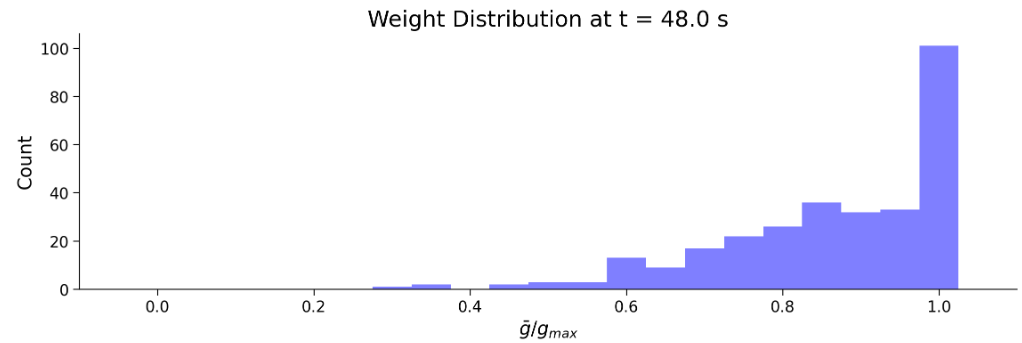
		$w$ 幾乎是飽和 ($飽和 = 0.024$)
		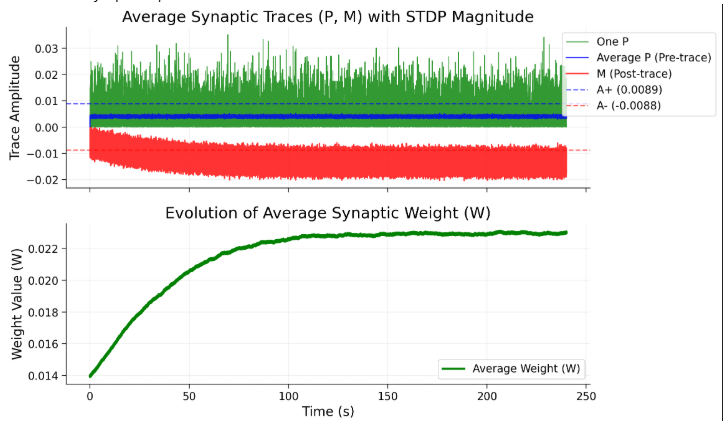
	* 整體的分析
		1. 因為 $A_+ > A_- \to w 大$
		2. $w 大 \to g_E 大$
		3. $\tau_m \frac{dv}{dt} = ... - \frac{g_E(t)}{g_L}(v - V_E)$ 變大
		4. Post spike 更容易發生 $\to w_j + P_j 更快發生$
		5. 這就導致 $P$ 來不及降直接給 $w$，和 2. 接上了成了一個迴圈，最終結果就是飽和
		6. 問題: post spike 更快發生了，$M = M - A_-$ 不也是瘋狂長?
			* 先推導: $\frac{dM(t)}{dt} = -\frac{M(t)}{\tau_{stdp}} - A_- \cdot S_{post}(t)$
				* $S_{post}(t)$ 當 post 的時候有值，類似狄拉克
				* 這個方程式把原本分步驟的 $P$ 計算方式整合成一條公式
				* 穩態後 $0 = \langle \frac{dM(t)}{dt} \rangle = -\frac{\langle M(t) \rangle}{\tau_{stdp}} - A_- \cdot \langle S_{post}(t) \rangle$
					* $\langle S_{post}(t) \rangle = r_{post}$
					* $M_{avg} = -A_- \cdot r_{post} \cdot \tau_{stdp}$
			* $\frac{dw}{dt} = \underbrace{r_{post} (A_+ r_{pre} \tau_{stdp})}_{\text{LTP 總加分}} + \underbrace{r_{pre} (-A_- r_{post} \tau_{stdp})}_{\text{LTD 總扣分}}$
			* $\frac{dw}{dt} = (A_+ - A_-) \cdot (r_{pre} \cdot r_{post} \cdot \tau_{stdp})$
				* $(A_+ - A_-) > 0$ 
			* 這個公式告訴我們穩態後 $\frac{dw}{dt}$ 依舊是漲
2. $A_- > A_+$
	* 但同條件下，不會明顯偏低，需要調整
	* $A_+ = 0.006$
	* $A_- = 0.0088$
	* pre spike 在 post spike 之後，但沒有相對的關係，沒有正向影響
		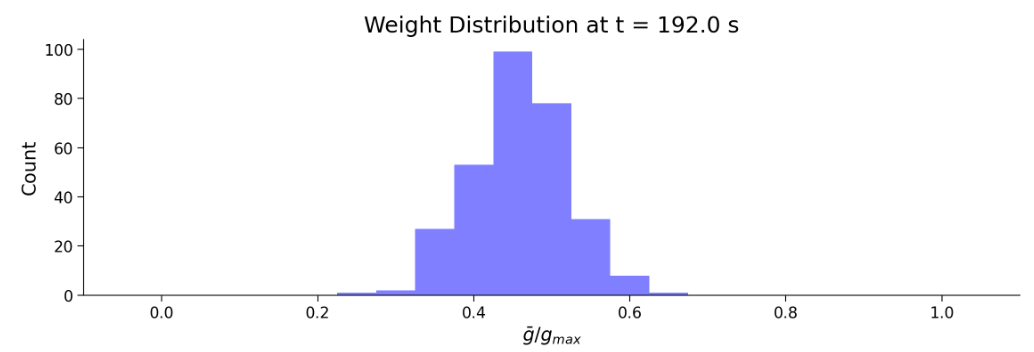
		但是確實可以看到 $w$ 是下降的 (注意: 這裡只降 0.003; $A_+ > A_-$ 是長了快 $0.01$)
		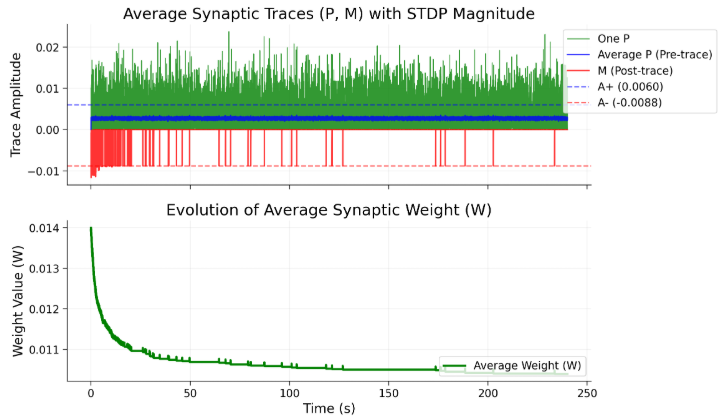
	* 為甚麼有這種差別待遇? 分析:
		1. $A_- > A_+ \to w 小$
		2. $w 小 \to g_E 小$
		3. $\tau_m \frac{dv}{dt} = ... - \frac{g_E(t)}{g_L}(v - V_E)$ 變小
		4. Post spike 不容易發生
			* $r_{post} = 0$
			* $M_{avg} = -A_- \cdot r_{post} \cdot \tau_{stdp}$
			* 這表示 $M$ 自殺了，這就導致 $\frac{dw}{dt} = (A_+ - A_-) \cdot (r_{pre} \cdot r_{post} \cdot \tau_{stdp}) = 0$
			
	* 但依舊是有成功抑制

		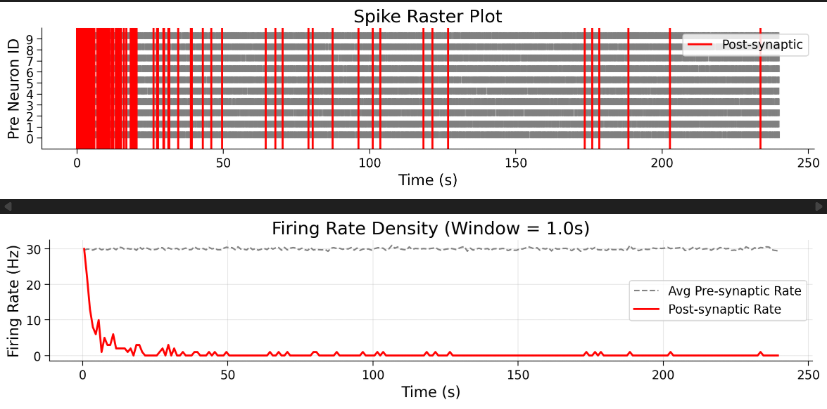
	* 實驗發現補上高 spike 頻率 $rate = 80 Hz$ 的情況下
		* 才會有明顯一點的偏負 

			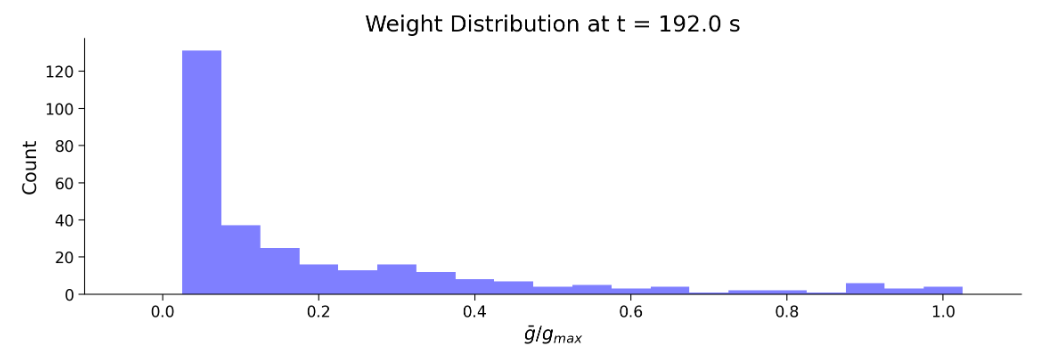
		* 解釋: 
			$\frac{dw}{dt} = (A_+ - A_-) \cdot (r_{pre} \cdot r_{post} \cdot \tau_{stdp}) = 0$
			* 相當於去暴力拉高 $r_{pre}$ 補上 $r_{post}$ 的無能

3. $A_+ \approx A_-$
	1. $A_+ = 0.0087, A_- = 0.0088$
		依舊是 

		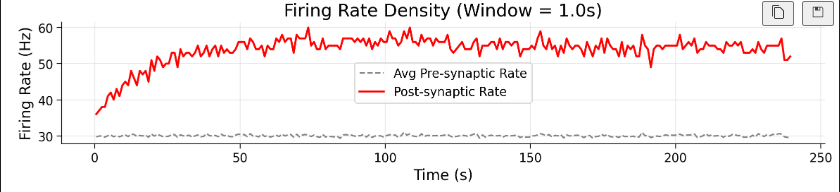

		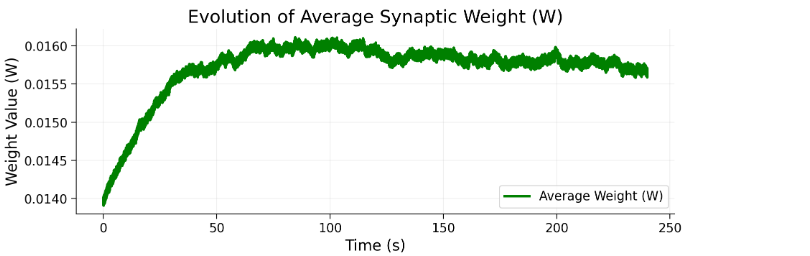
		* 解釋:
			* $\text{LTP 加分速度} \propto \text{瞬間開火機率} \propto \text{電壓跳躍} \propto w$
				* 把這串連鎖反應裡所有的常數（包含 $A_+, r_{pre}$ 等）全部打包成一個代號 $k$ 於是，LTP 的加分速度就變成了 $k \cdot w$
			* $\frac{dw}{dt} = kw - D$
				* $D \propto (A_- - A_+)$
				* $k > 0$
				* 穩態 $w_{critical} = \frac{D}{k}$
				*  $w < w_{critical}$: $kw < D$，$w$ 會越來越小
				*  $w > w_{critical}$: $kw > D$，$w$ 會越來越大
			* 因為 $(A_- - A_+)$ 極小，$D \approx 0$
				* $w_{critical} \approx 0$
					* 也說明很可能 $kw > D$
					* $\frac{dw}{dt} > 0 \to kw 大 \to \frac{dw}{dt}$ 更大
			* 這意思就是 $A_- - A_+$ 的影響力遠小於 $w_{init}$ 被隨機的 Possion 撿起來噴過限制
				
	2. 預設的參數 $A_+ = 0.0080, A_- = 0.0088$
		* 兩者相近的情況下，就會造成最終的 U 字形
		* 原本是全部混亂的權重，最後被整理成有大小之分，**而不是單純的鐘形分布**

		    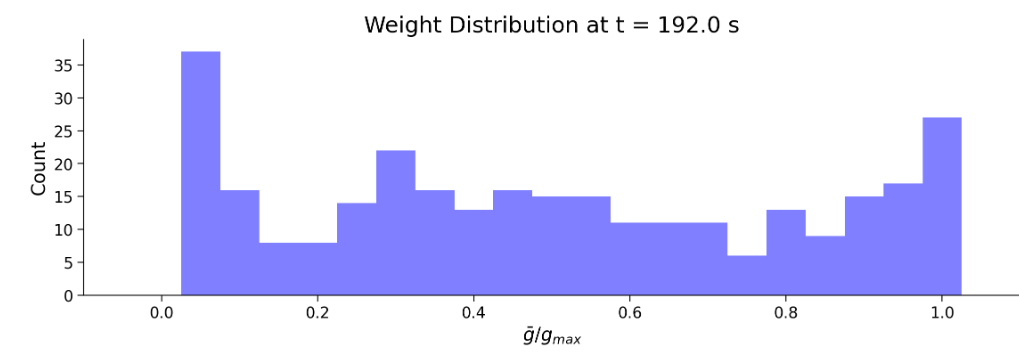 
		* 這就是突觸被分成 
			* $w > w_{critical}$
			* $w < w_{critical}$


## Section 3.5: Effect of Input Correlations on STDP

研究突觸前神經元的相關性如何影響突觸權重分布。

**假設**: 前 L 個神經元有相同的 spike train（完全相關），其餘神經元不相關。

In [13]:
def simulate_STDP_correlated(inputrate=15., Tsim=60000., n_neurons=300,
                              n_correlated=50, seed=2020):
    """
    STDP simulation with correlated inputs.
    """
    print(f"Simulating STDP with {n_correlated} correlated inputs...")
    starttime = time.perf_counter()

    np.random.seed(seed)
    pars = default_pars_STDP(T=Tsim, dt=1.)
    pars['gE_bar'] = 0.024
    pars['gE_init'] = 0.024 * np.random.rand(n_neurons)  # Random initial weights
    pars['VE'] = 0.
    pars['tau_syn_E'] = 5.

    pre_spike_train_ex = Poisson_generator(pars, rate=inputrate, n=n_neurons, myseed=seed)

    # Make first n_correlated neurons have identical spike trains
    for i in range(n_correlated):
        pre_spike_train_ex[i, :] = pre_spike_train_ex[0, :]

    v, rec_spikes, gE, P, M, gE_bar_update = run_LIF_cond_STDP(pars, pre_spike_train_ex)

    gbar_norm = gE_bar_update / pars['gE_bar']

    endtime = time.perf_counter()
    print(f"Simulation completed in {(endtime-starttime)/60:.2f} minutes")

    return {
        'pars': pars,
        'gE_bar_update': gE_bar_update,
        'gbar_norm': gbar_norm,
        'n_correlated': n_correlated
    }


def plot_correlated_STDP(results, sample_time_frac=1.0):
    """
    Plot STDP results with correlated vs uncorrelated inputs.
    """
    pars = results['pars']
    gE_bar_update = results['gE_bar_update']
    gbar_norm = results['gbar_norm']
    n_corr = results['n_correlated']

    sample_time = int(sample_time_frac * pars['range_t'].size) - 1

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))

    # Weight trajectories
    for i in range(min(n_corr, 50)):
        axes[0].plot(pars['range_t'][::1000] / 1000., gE_bar_update[i, ::1000],
                     'r', lw=0.5, alpha=0.7)
    for i in range(n_corr, min(n_corr+50, gE_bar_update.shape[0])):
        axes[0].plot(pars['range_t'][::1000] / 1000., gE_bar_update[i, ::1000],
                     'b', lw=0.5, alpha=0.5)
    axes[0].axvline(pars['range_t'][sample_time] / 1000., color='k', linestyle='--')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel(r'$\bar{g}$')
    axes[0].set_title('Weight Trajectories (Red=Correlated, Blue=Uncorrelated)')

    # Weight distributions
    bins = np.arange(-0.05, 1.05, 0.05)
    g_corr, _ = np.histogram(gbar_norm[:n_corr, sample_time], bins)
    g_uncorr, _ = np.histogram(gbar_norm[n_corr:, sample_time], bins)

    axes[1].bar(bins[1:] - 0.02, g_corr, color='r', alpha=0.5, width=0.04, label='Correlated')
    axes[1].bar(bins[1:] + 0.02, g_uncorr, color='b', alpha=0.5, width=0.04, label='Uncorrelated')
    axes[1].set_xlim(-0.1, 1.1)
    axes[1].set_xlabel(r'$\bar{g}/g_{max}$')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Weight Distribution at t = {pars["range_t"][sample_time]/1000:.1f} s')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Simulating STDP with 50 correlated inputs...
Simulation completed in 0.01 minutes


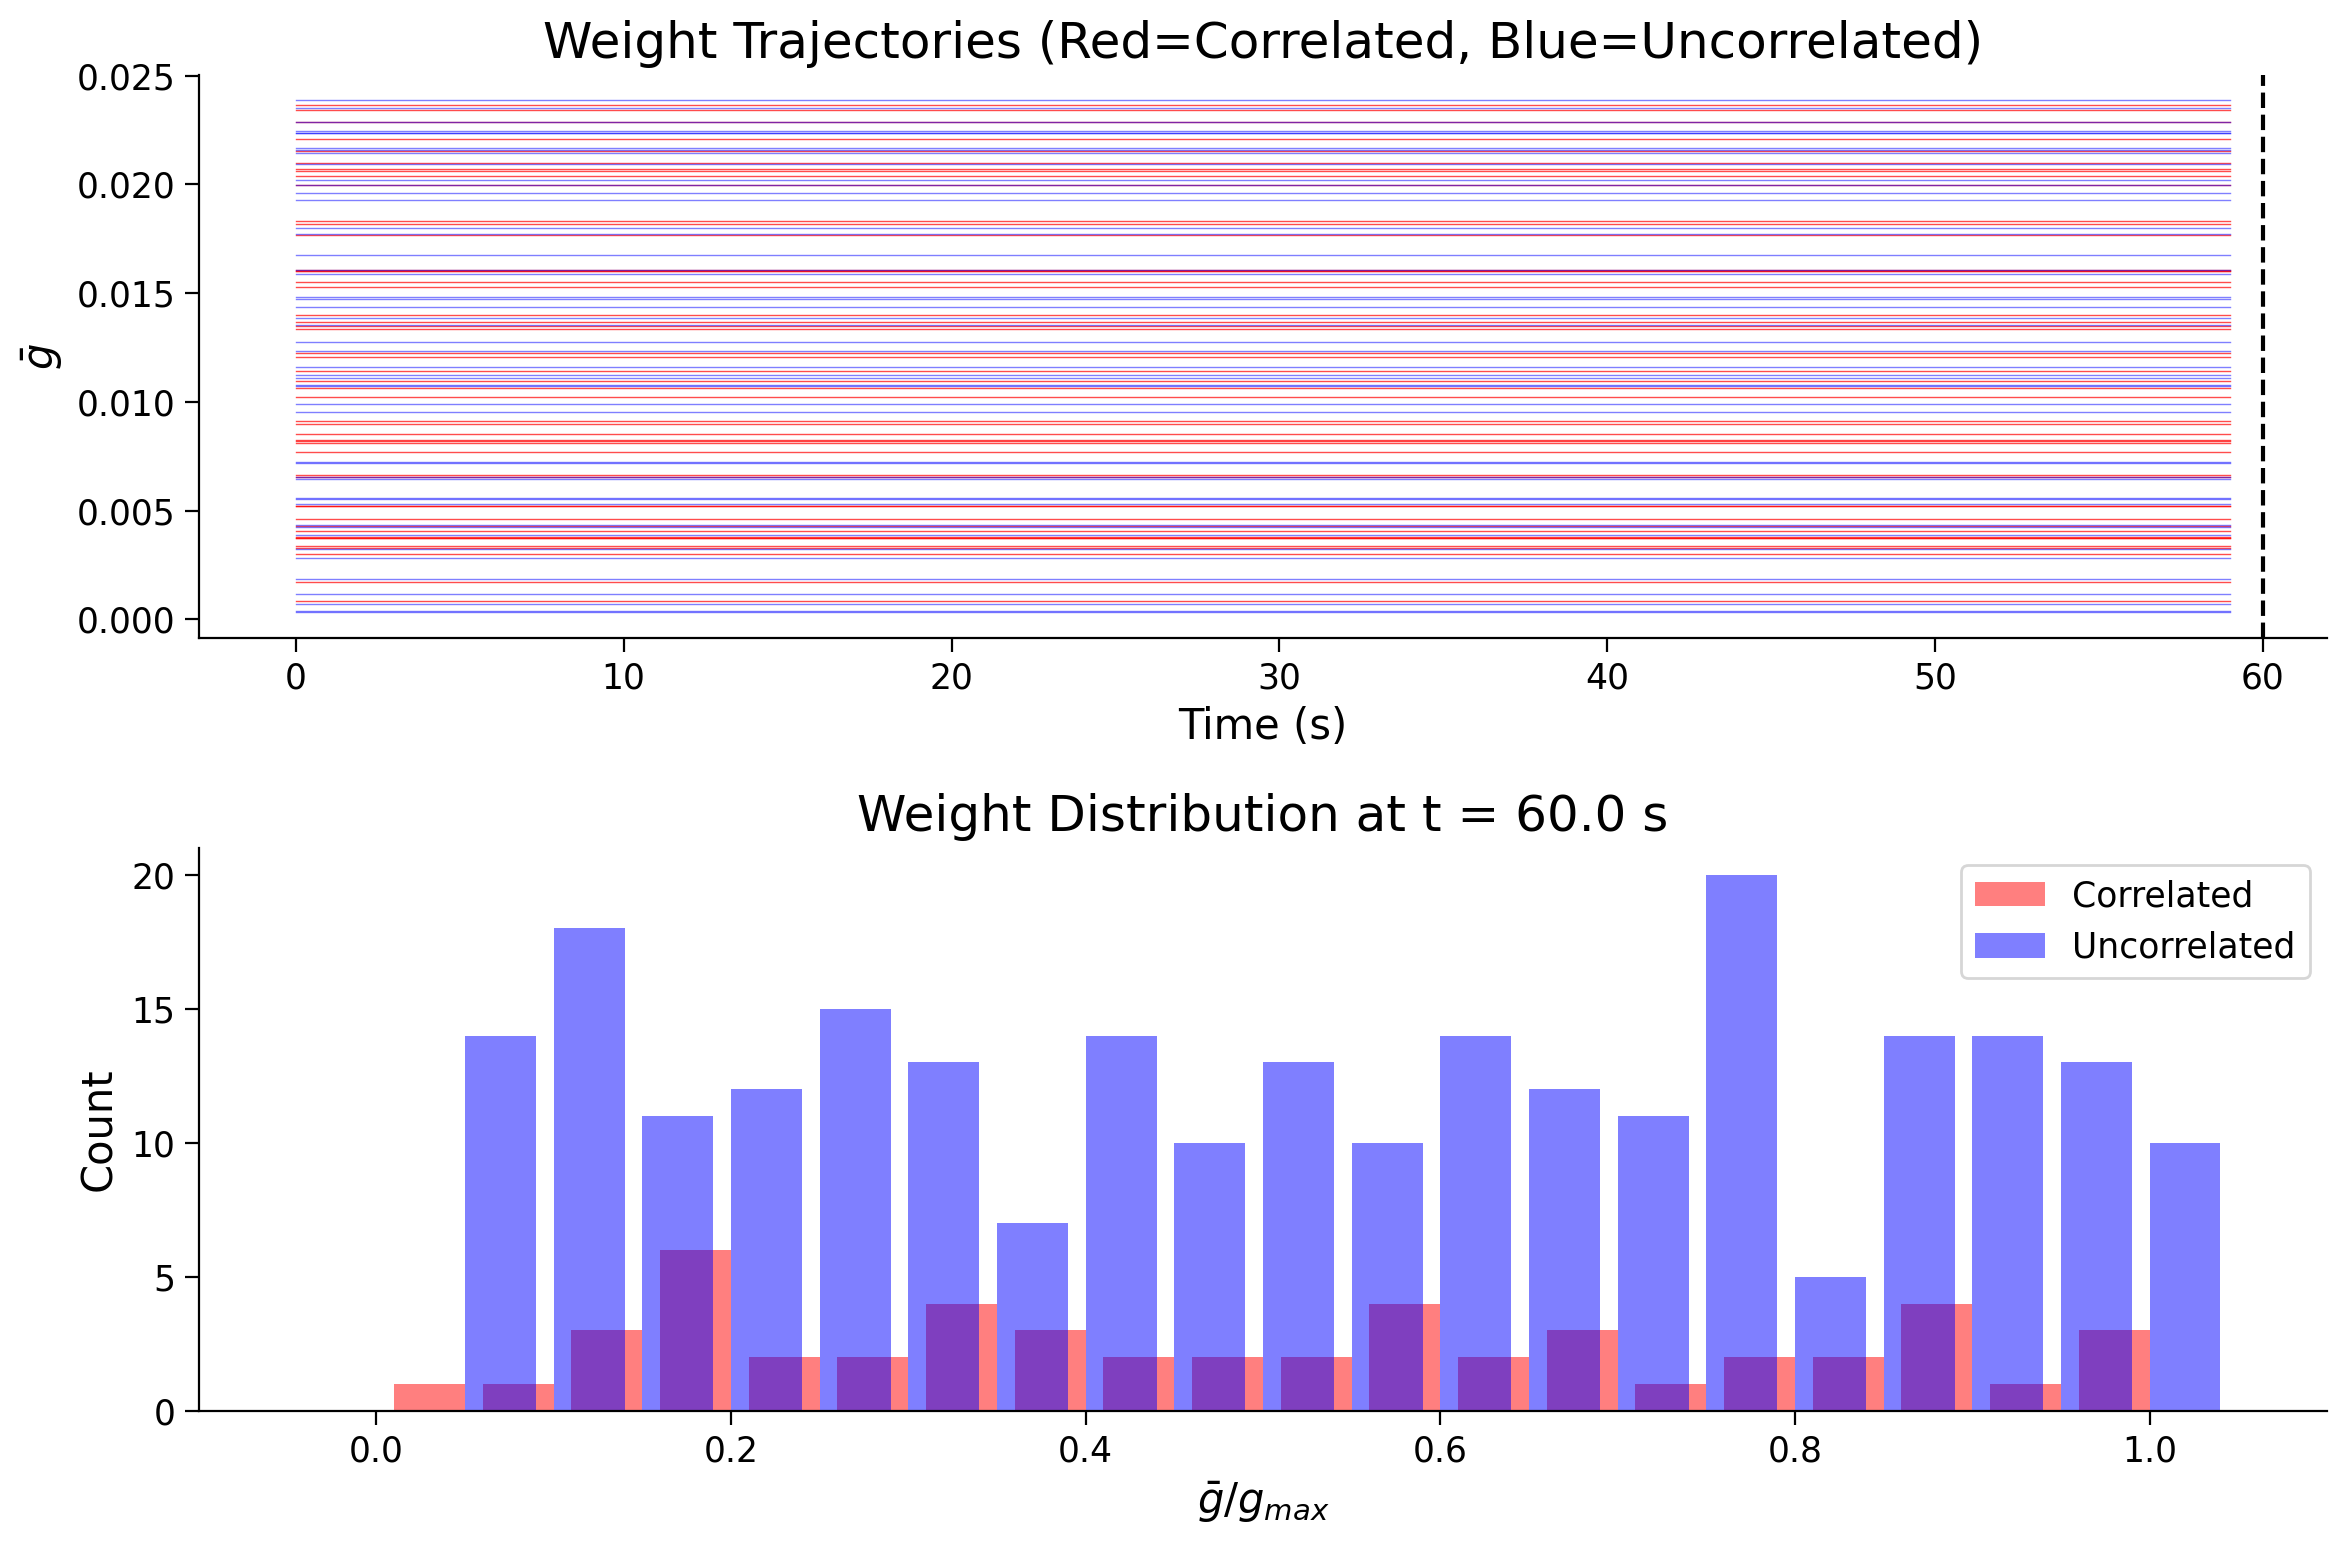

In [14]:
# Run STDP with correlated inputs
results_corr = simulate_STDP_correlated(inputrate=20., Tsim=60000.,
                                        n_neurons=300, n_correlated=50)

# Plot results
plot_correlated_STDP(results_corr, sample_time_frac=1.0)

---

# Summary

## Part 1: Static and Dynamic Synapses

1. **電導式突觸模型**: 使用 Brian2 模擬 LIF 神經元的突觸電導動力學
2. **自由膜電位 (FMP)**: 用於分析均值驅動 vs 波動驅動機制
3. **短期突觸可塑性 (STP)**:
   - **STD (Depression)**: 高頻率刺激導致突觸效能降低
   - **STF (Facilitation)**: 累積效應導致突觸效能增加

## Part 2: STDP

1. **STDP 學習規則**: 基於 spike 時序的突觸權重更新
   - Pre before Post → LTP (增強)
   - Post before Pre → LTD (抑制)

2. **Trace 變數**: P(t) 和 M(t) 用於追蹤 spike 歷史

3. **權重分布演變**: STDP 導致雙峰分布（強突觸和弱突觸）

4. **輸入相關性效應**: 相關輸入傾向於被增強（競爭性學習）

---

## Implementation Notes

本教程使用 **Brian2** 函數庫實現神經元模擬：
- `run_LIF_cond()`: 電導式 LIF 神經元（Brian2）
- `dynamic_syn()`: 短期突觸可塑性（Brian2）
- `run_LIF_cond_STDP()`: STDP 學習（混合 NumPy 實現）

所有核心函數都定義在 `lif_utils.py` 中。

---

## References

- Neuromatch Academy: Computational Neuroscience, W2D4
- Gerstner, W., & Kistler, W. M. (2002). Spiking neuron models
- Markram, H., et al. (1998). Differential signaling via the same axon of neocortical pyramidal neurons
- Bi, G., & Poo, M. (1998). Synaptic modifications in cultured hippocampal neurons